# Reward Competition: Consecutive Win/Loss Analysis

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)

from Reward_Training.rt_extension import Reward_Training
from rc_extension import Reward_Competition
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.stats import ttest_ind


In [2]:
experiment_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts"

manual_scoring_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\manual_scoring_combined.xlsx"

# hvl_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\HvL_comp_scoring_updated.xlsx"
hvl_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\combined_cohorts\HvL_comp_scoring_updated.xlsx"
# experiment_path = r"C:\Users\alber\OneDrive\Desktop\PC_Lab\Photometry\Pilot_2\Combined_Cohorts\Reward_Competition\Test"

# Set this to a saved .pkl from preprocess_reward_competition.py to skip shared preprocessing.
saved_rc_exp_path = r"C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\preprocessed_reward_competition.pkl"

In [3]:
if saved_rc_exp_path:
    rc_exp = Reward_Competition.load_preprocessed(saved_rc_exp_path)
else:
    rc_exp = Reward_Competition(experiment_folder_path=experiment_path, behavior_folder_path=None)
    rc_exp.rtc_processing()
    # rc_exp.read_manual_scoring(manual_scoring_path)
    # rc_exp.merge_data()

    rc_exp.read_and_merge_manual_scoring(manual_scoring_path)
    rc_exp.remove_specified_subjects()   # Remove specified subjects from the analysis
    rc_exp.read_hvl_scoring(hvl_path)
    # rc_exp.read_hvl_scoring_keep_ties(hvl_path)
    # print(rc_exp.trials_df)
    rc_exp.remove_tangles(placeholders= True)   # Remove sound cues and winner array indexes where there are tangles
    rc_exp.extract_da_columns()   # Grab only essential columns for analysis
    rc_exp.find_first_port_entry_after_sound_cue()

rc_exp.compute_EI_DA(tone_window=(-4,10),
                  pe_window=(-4,10),
                  baseline_window=(-20,-10))

# rc_exp.compute_EI_DA(tone_window=(-5,10),
#                   pe_window=(0,10),
#                   baseline_window=(-4,0))

rc_exp.compute_pretrial_EI_DA(pretrial_window=(-10,0),
                  baseline_window=(-14,-10))

rc_exp.compute_rtc_da_metrics(include_pretrial=True, bout_duration=4)

Loaded Reward_Competition object from C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\preprocessed_reward_competition.pkl


,subject_name,file name,trial,filtered_sound_cues,filtered_port_entries,filtered_port_entry_offset,filtered_winner_array,HVL_PreComp,HVL_Comp,first_PE_after_sound_cue,...,Tone Time of Max Peak,Tone Mean Z-score,PE AUC,PE Max Peak,PE Time of Max Peak,PE Mean Z-score,Pretrial AUC,Pretrial Max Peak,Pretrial Time of Max Peak,Pretrial Mean Z-score
0,nn5,nn5-250203-080636,<trial_class.Trial object at 0x0000024B47884440>,"[241.12775168, 321.12836608, 411.12895488, 491...","[184.1774592, 185.80733952, 193.31743744, 285....","[184.47745024, 187.45769984, 193.45752064, 285...","[tie, nn8, nn8, nn8, nn8, nn8, nn8, nn8, nn8, ...","[nan, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[285.35799808, 325.12836608, 415.12895488, 495...",...,"[0.7599999998874409, 0.7299999998881503, 0.849...","[0.5802336747137781, 1.062853039739788, 0.3513...","[0.6000097100646311, 0.8140182487434247, 1.304...","[1.6889885135579903, 1.0771713947220714, 1.236...","[0.009999999905176082, 3.3299999998266685, 1.7...","[0.1515680416539216, 0.20333772067201256, 0.32...","[-2.849382550168764, -1.3336872573869143, 0.66...","[0.5931472481063685, 1.0071056302787829, 1.468...","[-8.490000000035707, -3.4200000001555964, -0.8...","[-0.2852658182810076, -0.1337081639029117, 0.0..."
1,pp5,pp5-250203-080636,<trial_class.Trial object at 0x0000024B47884D70>,"[241.12775168, 321.12836608, 411.12895488, 491...","[181.1275776, 184.02738176, 185.90744576, 187....","[181.68741888, 185.52766464, 186.98747904, 187...","[pp5, pp5, pp5, pp5, pp8, pp5, pp8, tangle, ta...","[0.0, 0.0, nan, 1.0, 1.0, 0.0, nan, nan, nan, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, nan, nan, ...","[245.12775168, 325.12836608, 415.12895488, 495...",...,"[1.5599999998685234, 0.309999999898082, 3.9999...","[0.2669676790824083, 0.18525235677172888, -0.6...","[5.9460029167875, 0.019144572599193957, 2.2889...","[2.8878636660304693, 1.4146806890012817, 1.390...","[1.6799999998656858, 2.7699999998399107, 3.549...","[1.4891253205924435, 0.003496763712202551, 0.5...","[1.8332802116328355, 1.7517189334442307, 2.378...","[1.4933537085859405, 1.404225722707683, 2.0700...","[-2.9000000001678927, -9.35000000001537, -6.44...","[0.1830518255475024, 0.1757293702764755, 0.237..."
2,nn1,nn1-250203-085508,<trial_class.Trial object at 0x0000024B47706390>,"[250.00820736, 330.00865792, 420.00941056, 500...","[194.11779584, 203.48796928, 215.75778304, 217...","[196.25771008, 206.667776, 217.06801152, 217.8...","[nn2, nn1, nn1, nn1, nn1, nn1, nn2, nn2, nn1, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, nan, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, nan, 0.0, ...","[254.00820736, 334.00865792, 424.00941056, 504...",...,"[1.7699999998635576, 0.7599999998874409, 0.919...","[-0.526037643077045, 0.7905916884706119, 0.634...","[-0.3843073416680337, 3.211606795797126, 1.826...","[0.4053416088484894, 4.294016009075808, 2.3342...","[2.079999999856227, 0.8999999998841304, 0.8299...","[-0.09619990018066658, 0.8013506900651002, 0.4...","[-6.219682915576498, -4.024362126982294, -5.54...","[1.4058687016702707, 0.7591264878106921, 2.433...","[-9.640000000008513, -9.910000000002128, -6.30...","[-0.6218682903413478, -0.4018647191271188, -0...."
3,nn3,nn3-250203-085508,<trial_class.Trial object at 0x0000024B47706CF0>,"[250.00820736, 330.00865792, 420.00941056, 500...","[219.1179776, 230.92805632, 231.34830592, 244....","[225.37814016, 231.26818816, 232.78813184, 246...","[nn3, nn4, nn3, nn4, nn4, nn4, nn4, nn4, nn4, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[254.00820736, 334.00865792, 424.00941056, 504...",...,"[0.8099999998862586, 0.7199999998883868, 0.699...","[1.9646313990391695, 0.9896661193313239, 2.228...","[9.05791996589164, 1.5704923499887316, 10.8684...","[5.703915277585182, 1.282415099616726, 7.44185...","[1.1599999998779822, 2.5999999998439307, 1.059...","[2.2668160177785297, 0.3940374969289691, 2.718...","[-6.01783543321439

In [4]:
rc_exp.da_df['HVL_Comp']

0     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, nan, nan, ...
2     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, nan, nan, 0.0, ...
3     [0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...
4     [0.0, 1.0, nan, 0.0, 0.0, nan, 0.0, 0.0, 0.0, ...
                            ...                        
66                                                   []
67    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
68    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
69    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
70    [0.0, 0.0, 0.0, 0.0, nan, 0.0, 0.0, 0.0, 0.0, ...
Name: HVL_Comp, Length: 71, dtype: object

In [8]:
rc_exp.da_df.columns

Index(['subject_name', 'file name', 'trial', 'filtered_sound_cues',
       'filtered_port_entries', 'filtered_port_entry_offset',
       'filtered_winner_array', 'HVL_PreComp', 'HVL_Comp',
       'first_PE_after_sound_cue', 'Tone_Time_Axis', 'Tone_Zscore',
       'PE_Time_Axis', 'PE_Zscore', 'Pretrial_Time_Axis', 'Pretrial_Zscore',
       'Tone AUC', 'Tone Max Peak', 'Tone Time of Max Peak',
       'Tone Mean Z-score', 'PE AUC', 'PE Max Peak', 'PE Time of Max Peak',
       'PE Mean Z-score', 'Pretrial AUC', 'Pretrial Max Peak',
       'Pretrial Time of Max Peak', 'Pretrial Mean Z-score'],
      dtype='object')

In [9]:
rc_exp.da_df[['subject_name','HVL_PreComp', 'Pretrial AUC', 'filtered_winner_array','Pretrial_Zscore','Pretrial_Time_Axis']].head(0)
# rc_exp.da_df.columns

,subject_name,HVL_PreComp,Pretrial AUC,filtered_winner_array,Pretrial_Zscore,Pretrial_Time_Axis


## Pretrial

Explode based on pretrial or trial

In [10]:
def explode_event_traces(
    df: pd.DataFrame,
    comp_col:      str,
    time_col:      str,
    trace_col:     str,
    array_cols:    list[str]  = None
) -> pd.DataFrame:
    """
    For each session-row in df, explodes each event i into its own row:
      subject_name | comp | time (1d-array) | trace (1d-array) | <other array cols>...
    Drops any events where comp is nan.

    Parameters
    ----------
    df : DataFrame
        Must contain at least columns [subject_name, comp_col, time_col, trace_col]
        and any array_cols you want to carry along.
    comp_col, time_col, trace_col : str
        Column names holding lists/arrays of comps, time axes, and traces.
    array_cols : list[str]
        List of additional column names in `df` whose values are lists/arrays
        of the same length.  Each element at index i will be picked into the
        exploded row.  If None, no extras are grabbed.

    Returns
    -------
    exploded : DataFrame
        One row per event, with scalar comp and array-valued time/trace, plus
        scalar or array values for each array_cols entry.
    """
    if array_cols is None:
        array_cols = []

    rows = []
    for _, row in df.iterrows():
        subj   = row['subject_name']
        comps  = row.get(comp_col)  or []
        times  = row.get(time_col)  or []
        traces = row.get(trace_col) or []
        # get other arrays, default to [] if missing
        extras = {
            col: (row.get(col) or [])
            for col in array_cols
        }

        n = max(len(comps), len(times), len(traces), 
                *[len(extras[col]) for col in array_cols])

        for i in range(n):
            c = comps[i]  if i < len(comps)  else np.nan
            if pd.isna(c):
                continue

            t = times[i]  if i < len(times)  else []
            z = traces[i] if i < len(traces) else []

            # build base dict
            out = {
                'subject_name': subj,
                'comp':         int(c),
                'time':         np.asarray(t, dtype=float),
                'trace':        np.asarray(z, dtype=float),
            }

            # add each extra column element
            for col in array_cols:
                arr = extras[col]
                out[col] = arr[i] if i < len(arr) else np.nan

            rows.append(out)

    return pd.DataFrame(rows)



def explode_event_traces_ties(
    df: pd.DataFrame,
    comp_col:      str,
    time_col:      str,
    trace_col:     str,
    array_cols:    list[str]  = None,
    *,
    tie_mask_col:  str | None = None,     # optional boolean list column marking ties
    tie_tokens:    tuple = ("T", "t", "tie", "Tie", "TIE"),
    keep_ties:     bool = True,           # include tie rows?
    ties_only:     bool = True,          # include ONLY tie rows?
    drop_missing_non_tie: bool = True     # drop rows where comp is missing and not a tie
) -> pd.DataFrame:
    """
    Explode per-event arrays to rows, preserving 'ties'.

    - If `tie_mask_col` is provided, an event is a tie when that mask[i] is True.
    - Otherwise, an event is a tie if comp equals a string in `tie_tokens` OR comp is NaN.
    - Adds an `outcome` column: 'tie' or 'non-tie'.
    - Keeps both original `comp_raw` and a numeric `comp_num` (when castable).

    Returns one row per event with:
      subject_name | outcome | comp_raw | comp_num | time | trace | <array_cols>...
    """
    if array_cols is None:
        array_cols = []

    def _is_tie(i, comps, row):
        # Priority: explicit boolean tie mask if provided
        if tie_mask_col is not None:
            mask = row.get(tie_mask_col) or []
            return (i < len(mask)) and bool(mask[i])
        # Fallback: detect ties from comp token or NaN
        c = comps[i] if i < len(comps) else np.nan
        if isinstance(c, str) and c.strip() in tie_tokens:
            return True
        return pd.isna(c)

    def _to_int_or_nan(x):
        # best-effort numeric cast; return np.nan if not numeric
        try:
            if pd.isna(x): 
                return np.nan
        except Exception:
            pass
        try:
            # allow float-like "3.0" or "3"
            v = float(x)
            if np.isnan(v):
                return np.nan
            return int(v)
        except Exception:
            return np.nan

    rows = []
    for _, row in df.iterrows():
        subj   = row['subject_name']
        comps  = row.get(comp_col)  or []
        times  = row.get(time_col)  or []
        traces = row.get(trace_col) or []
        extras = {col: (row.get(col) or []) for col in array_cols}

        n = max(len(comps), len(times), len(traces), *[len(extras[col]) for col in array_cols] or [0])

        for i in range(n):
            tie = _is_tie(i, comps, row)

            # filtering logic for ties
            if ties_only and not tie:
                continue
            if not keep_ties and tie:
                continue

            c_raw = comps[i] if i < len(comps) else np.nan
            # if not a tie and comp is missing, optionally drop
            if (not tie) and drop_missing_non_tie and pd.isna(c_raw):
                continue

            t = times[i]  if i < len(times)  else []
            z = traces[i] if i < len(traces) else []

            out = {
                'subject_name': subj,
                'outcome':      'tie' if tie else 'non-tie',
                'comp_raw':     c_raw,                         # preserves original token/number
                'comp':     _to_int_or_nan(c_raw),         # numeric when possible, else NaN
                'time':         np.asarray(t, dtype=float),
                'trace':        np.asarray(z, dtype=float),
            }
            for col in array_cols:
                arr = extras[col]
                out[col] = arr[i] if i < len(arr) else np.nan

            rows.append(out)

    return pd.DataFrame(rows)


In [11]:
def plot_psth_for_region(
    exploded_df: pd.DataFrame,
    region:      str   = 'NAc',           # choose 'NAc' or 'mPFC'
    time_col:    str   = 'time',
    trace_col:   str   = 'trace',
    comp_col:    str   = 'comp',
    time_window: tuple = (-5.0, 10.0),
    line_at:     float = 4.0,
    colors:      tuple = ('#a839a4', '#43246a'),  # hex color codes
    labels:      tuple = ('Low comp', 'High comp'),
    figsize:     tuple = (11,8),
    title:       str   = None,            # user-defined title
    ylims:       tuple = None             # user-defined y-axis limits (min, max)
):
    """
    Plot mean Ã‚Â± SEM PSTH for a single region (NAc or mPFC),
    split by low vs. high comp. Colors can be hex codes.
    """
    # map region name Ã¢â€ â€™ subject_name prefix
    prefix_map = {'NAc': 'n', 'mPFC': 'p'}
    if region not in prefix_map:
        raise ValueError(f"region must be one of {list(prefix_map)}")
    prefix = prefix_map[region]

    # --- 1) find the smallest dt across all events ---
    all_dts = [
        np.min(np.diff(t))
        for t in exploded_df[time_col]
        if getattr(t, "size", 0) > 1
    ]
    if not all_dts:
        raise RuntimeError("No valid ÃŽâ€t found in time axes!")
    dt = min(all_dts)

    # --- 2) build common time axis ---
    t0, t1 = time_window
    common_t = np.arange(t0, t1 + dt/2, dt)

    # --- 3) filter to this region ---
    sub = exploded_df[exploded_df['subject_name'].str.startswith(prefix)]
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    if sub.empty:
        ax.set_title(f"No data for {region}", fontsize=36)
        ax.axis('off')
        plt.show()
        return

    # --- 4) compute & plot low vs. high comp ---
    for comp_val, lbl, col in zip((0, 1), labels, colors):
        grp = sub[sub[comp_col] == comp_val]
        if grp.empty:
            continue

        mats = []
        for _, row in grp.iterrows():
            t_evt = row[time_col]
            z_evt = row[trace_col]
            z_i = np.interp(
                common_t, t_evt, z_evt,
                left=np.nan, right=np.nan
            )
            mats.append(z_i)

        M = np.vstack(mats)
        mean_trace = np.nanmean(M, axis=0)
        sem_trace  = np.nanstd(M, axis=0, ddof=1) / np.sqrt(M.shape[0])

        ax.plot(common_t, mean_trace, lw=2, label=lbl, color=col)
        ax.fill_between(common_t,
                        mean_trace - sem_trace,
                        mean_trace + sem_trace,
                        alpha=0.3, color=col)

    # --- 5) styling ---
    ax.axvline(0, color='k', ls='--', lw=1.5)
    ax.axvline(line_at, color='red', ls='--', lw=1.5)

    # Title
    plot_title = title if title is not None else f"{region} High vs. Low Comp"
    ax.set_title(plot_title, fontsize=36, pad=40)

    # Axis labels
    ax.set_xlim(time_window)
    if ylims is not None:
        ax.set_ylim(ylims)
    ax.set_xlabel("Time (s)", fontsize=37)
    ax.set_ylabel("Event-Induced z-scored ÃŽâ€F/F", fontsize=37, labelpad=15)
    ax.tick_params(axis='both', which='major', labelsize=30)

    # Legend
    ax.legend(frameon=False, fontsize=20, loc='upper right')

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()


In [12]:
CONSECUTIVE_OUTCOME_COLORS = {
    'win-win':  '#1b9e77',
    'win-loss': '#d95f02',
    'loss-win': '#7570b3',
    'loss-loss':'#e7298a',
}


def _winner_to_outcome(subject_name, winner):
    if pd.isna(winner):
        return np.nan
    winner_str = str(winner).strip()
    if winner_str == '' or winner_str.lower() in {'t', 'tie', 'nan', 'none'}:
        return np.nan
    return 'win' if winner_str == str(subject_name) else 'loss'


def explode_consecutive_outcome_traces(
    df: pd.DataFrame,
    *,
    time_col: str,
    trace_col: str,
    winner_col: str = 'filtered_winner_array',
    array_cols: list[str] | None = None,
) -> pd.DataFrame:
    """
    Build one row per event, labeled by the previous and current
    non-tie outcome within each session/recording.

    Output rows correspond to the *current* trial in each consecutive pair.
    Labels are one of: win-win, win-loss, loss-win, loss-loss.
    """
    if array_cols is None:
        array_cols = []

    rows = []
    for _, row in df.iterrows():
        subj = row['subject_name']
        file_name = row.get('file name', np.nan)
        trial_obj = row.get('trial', np.nan)
        winners = row.get(winner_col) or []
        times = row.get(time_col) or []
        traces = row.get(trace_col) or []
        extras = {col: (row.get(col) or []) for col in array_cols}

        n = max(len(winners), len(times), len(traces), *[len(extras[col]) for col in array_cols] or [0])
        outcomes = [_winner_to_outcome(subj, winners[i] if i < len(winners) else np.nan) for i in range(n)]

        for i in range(1, n):
            prev_outcome = outcomes[i - 1]
            curr_outcome = outcomes[i]
            if pd.isna(prev_outcome) or pd.isna(curr_outcome):
                continue

            t = times[i] if i < len(times) else []
            z = traces[i] if i < len(traces) else []
            if len(t) == 0 or len(z) == 0:
                continue

            out = {
                'subject_name': subj,
                'file name': file_name,
                'trial': trial_obj,
                'event_index': i,
                'winner': winners[i] if i < len(winners) else np.nan,
                'prev_outcome': prev_outcome,
                'curr_outcome': curr_outcome,
                'sequence': f'{prev_outcome}-{curr_outcome}',
                'time': np.asarray(t, dtype=float),
                'trace': np.asarray(z, dtype=float),
            }
            for col in array_cols:
                arr = extras[col]
                out[col] = arr[i] if i < len(arr) else np.nan
            rows.append(out)

    return pd.DataFrame(rows)


def build_consecutive_outcome_exploded(
    df: pd.DataFrame,
    *,
    align_to: str = 'tone',
    pe_time_reference: str = 'pe',
) -> pd.DataFrame:
    align_to = align_to.lower()
    if align_to == 'tone':
        time_col = 'Tone_Time_Axis'
        trace_col = 'Tone_Zscore'
        extra_cols = [
            'filtered_winner_array', 'HVL_Comp', 'Tone_Time_Axis', 'Tone_Zscore',
            'Tone AUC', 'Tone Max Peak', 'Tone Time of Max Peak', 'Tone Mean Z-score',
            'first_PE_after_sound_cue',
        ]
    elif align_to == 'pe':
        time_col = 'PE_Time_Axis'
        trace_col = 'PE_Zscore'
        extra_cols = [
            'filtered_winner_array', 'HVL_Comp', 'PE_Time_Axis', 'PE_Zscore',
            'PE AUC', 'PE Max Peak', 'PE Time of Max Peak', 'PE Mean Z-score',
            'first_PE_after_sound_cue',
        ]
    else:
        raise ValueError("align_to must be 'tone' or 'pe'")

    exploded = explode_consecutive_outcome_traces(
        df,
        time_col=time_col,
        trace_col=trace_col,
        winner_col='filtered_winner_array',
        array_cols=extra_cols,
    )

    if align_to == 'pe':
        pe_time_reference = pe_time_reference.lower()
        if pe_time_reference not in {'pe', 'tone'}:
            raise ValueError("pe_time_reference must be 'pe' or 'tone'")

        # PE_Zscore already preserves the upstream tone-referenced baseline from compute_EI_DA.
        # Only shift the x-axis if you explicitly want to view PE-aligned traces on tone time.
        if pe_time_reference == 'tone' and not exploded.empty:
            def _shift_to_tone_time(row):
                t = row['time']
                pe_onset = row.get('first_PE_after_sound_cue', np.nan)
                if getattr(t, 'size', 0) == 0 or pd.isna(pe_onset):
                    return t
                return np.asarray(t, dtype=float) + float(pe_onset)

            exploded['time'] = exploded.apply(_shift_to_tone_time, axis=1)

    return exploded


def plot_consecutive_outcome_psth(
    exploded_df: pd.DataFrame,
    *,
    region: str,
    align_to: str = 'tone',
    time_col: str = 'time',
    trace_col: str = 'trace',
    sequence_col: str = 'sequence',
    sequences: tuple[str, ...] = ('win-win', 'win-loss', 'loss-win', 'loss-loss'),
    sequence_colors: dict[str, str] | list[str] | tuple[str, ...] | None = None,
    time_window: tuple | None = None,
    ylims: tuple | None = None,
    event_line_at: float = 0.0,
    figsize: tuple = (9, 6),
    title: str | None = None,
    background_color: str = 'none',
    font_size: int = 16,
    label_font_size: int | None = None,
    tick_font_size: int | None = None,
    title_font_size: int | None = None,
    legend_font_size: int | None = None,
    axis_line_width: float = 2.0,
    tick_width: float | None = None,
):
    prefix_map = {'NAc': 'n', 'mPFC': 'p'}
    if region not in prefix_map:
        raise ValueError("region must be 'NAc' or 'mPFC'")
    pfx = prefix_map[region]

    if sequence_colors is None:
        color_map = {seq: CONSECUTIVE_OUTCOME_COLORS.get(seq, None) for seq in sequences}
    elif isinstance(sequence_colors, dict):
        color_map = {seq: sequence_colors.get(seq, CONSECUTIVE_OUTCOME_COLORS.get(seq, None)) for seq in sequences}
    else:
        if len(sequence_colors) != len(sequences):
            raise ValueError(f"sequence_colors must have {len(sequences)} colors, one for each sequence")
        color_map = dict(zip(sequences, sequence_colors))

    label_font_size = font_size if label_font_size is None else label_font_size
    tick_font_size = max(font_size - 2, 1) if tick_font_size is None else tick_font_size
    title_font_size = font_size if title_font_size is None else title_font_size
    legend_font_size = max(font_size - 2, 1) if legend_font_size is None else legend_font_size
    tick_width = axis_line_width if tick_width is None else tick_width

    sub = exploded_df[exploded_df['subject_name'].astype(str).str.startswith(pfx)].copy()
    if sub.empty:
        raise ValueError(f"No data for region {region}")

    all_dts = [np.min(np.diff(t)) for t in sub[time_col] if getattr(t, 'size', 0) > 1]
    if not all_dts:
        raise RuntimeError("No valid dt found in time axes")
    dt = min(all_dts)

    if time_window is None:
        tmins = [np.nanmin(t) for t in sub[time_col] if getattr(t, 'size', 0) > 0]
        tmaxs = [np.nanmax(t) for t in sub[time_col] if getattr(t, 'size', 0) > 0]
        time_window = (float(np.nanmin(tmins)), float(np.nanmax(tmaxs)))

    t0, t1 = time_window
    common_t = np.arange(t0, t1 + dt / 2, dt)

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    fig.patch.set_facecolor(background_color)
    ax.set_facecolor(background_color)

    for seq in sequences:
        grp = sub[sub[sequence_col] == seq]
        if grp.empty:
            continue

        mats = []
        for _, row in grp.iterrows():
            zi = np.interp(common_t, row[time_col], row[trace_col], left=np.nan, right=np.nan)
            mats.append(zi)

        M = np.vstack(mats)
        mean_trace = np.nanmean(M, axis=0)
        sem_trace = np.nanstd(M, axis=0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros_like(common_t)
        color = color_map.get(seq, None)

        ax.plot(common_t, mean_trace, lw=2.5, color=color, label=f"{seq} (n={len(grp)})")
        ax.fill_between(common_t, mean_trace - sem_trace, mean_trace + sem_trace, color=color, alpha=0.2)

    ax.axvline(event_line_at, color='k', ls='--', lw=1.5)
    ax.set_xlim(time_window)
    if ylims is not None:
        ax.set_ylim(ylims)
    ax.set_xlabel('Time (s)', fontsize=label_font_size)
    ax.set_ylabel(r'Event-Induced z-scored $\Delta$F/F', fontsize=label_font_size)
    ax.tick_params(axis='both', which='major', labelsize=tick_font_size, width=tick_width)
    if title:
        ax.set_title(title, fontsize=title_font_size)
    ax.legend(
        loc='upper left',
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        frameon=True,
        facecolor='white',
        edgecolor='black',
        framealpha=1.0,
        fancybox=False,
        fontsize=legend_font_size,
    )
    for spine in ax.spines.values():
        spine.set_linewidth(axis_line_width)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()


## Consecutive Win/Loss PSTHs

In [13]:
tone_consecutive_exploded = build_consecutive_outcome_exploded(
    rc_exp.da_df,
    align_to='tone',
)

pe_consecutive_exploded = build_consecutive_outcome_exploded(
    rc_exp.da_df,
    align_to='pe',
    pe_time_reference='pe',
)

tone_consecutive_exploded.head()


,subject_name,file name,trial,event_index,winner,prev_outcome,curr_outcome,sequence,time,trace,filtered_winner_array,HVL_Comp,Tone_Time_Axis,Tone_Zscore,Tone AUC,Tone Max Peak,Tone Time of Max Peak,Tone Mean Z-score,first_PE_after_sound_cue
0,nn5,nn5-250203-080636,<trial_class.Trial object at 0x0000020F50E801D0>,2,nn8,loss,loss,loss-loss,"[-4.0, -3.9900000000002365, -3.980000000000473...","[0.11125790967278143, 0.1334276211831586, 0.15...",nn8,0.0,"[-4.0, -3.9900000000002365, -3.980000000000473...","[0.11125790967278143, 0.1334276211831586, 0.15...",1.408282,2.629418,0.85,0.351382,415.128955
1,nn5,nn5-250203-080636,<trial_class.Trial object at 0x0000020F50E801D0>,3,nn8,loss,loss,loss-loss,"[-4.0, -3.9900000000002365, -3.980000000000473...","[3.2396173457342083, 3.1486617115839857, 3.055...",nn8,0.0,"[-4.0, -3.9900000000002365, -3.980000000000473...","[3.2396173457342083, 3.1486617115839857, 3.055...",2.464941,3.085644,1.01,0.615346,495.129733
2,nn5,nn5-250203-080636,<trial_class.Trial object at 0x0000020F50E801D0>,4,nn8,loss,loss,loss-loss,"[-4.0, -3.9900000000002365, -3.980000000000473...","[2.607748360131639, 2.6078067099260336, 2.6129...",nn8,0.0,"[-4.0, -3.9900000000002365, -3.980000000000473...","[2.607748360131639, 2.6078067099260336, 2.6129...",7.157302,5.492553,0.78,1.790028,570.130115
3,nn5,nn5-250203-080636,<trial_class.Trial object at 0x0000020F50E801D0>,5,nn8,loss,loss,loss-loss,"[-4.0, -3.9900000000002365, -3.980000000000473...","[0.23388348047750887, 0.23404838700837974, 0.2...",nn8,0.0,"[-4.0, -3.9900000000002365, -3.980000000000473...","[0.23388348047750887, 0.23404838700837974, 0.2...",1.953633,2.599752,1.10,0.487845,670.130514
4,nn5,nn5-250203-080636,<trial_class.Trial object at 0x0000020F50E801D0>,6,nn8,loss,loss,loss-loss,"[-4.0, -3.9900000000002365, -3.980000000000473...","[-0.7222437193797486, -0.7243167244515017, -0....",nn8,0.0,"[-4.0, -3.9900000000002365, -3.980000000000473...","[-0.7222437193797486, -0.7243167244515017, -0....",-2.346141,0.452588,1.16,-0.588867,765.131172


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


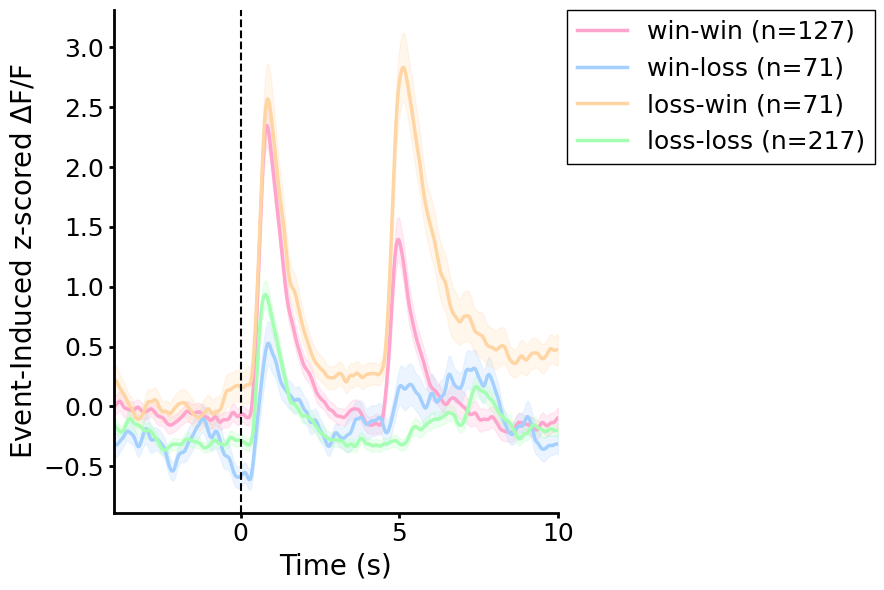

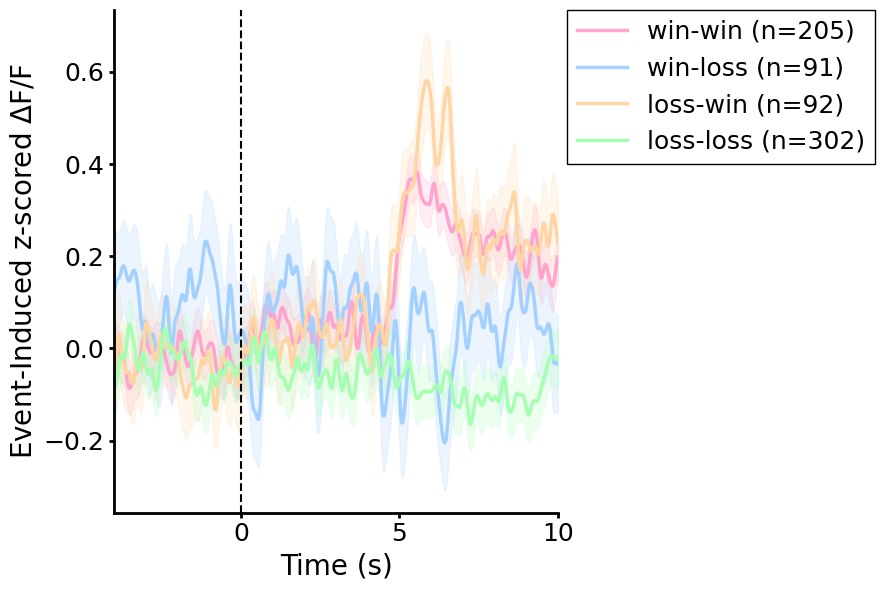

In [14]:
for region in ['NAc', 'mPFC']:
    plot_consecutive_outcome_psth(
        tone_consecutive_exploded,
        region=region,
        align_to='tone',
        event_line_at=0.0,
        title=None,
        background_color='none',
        font_size=20,
        sequence_colors=['#ffa4cd', '#a4d0ff', '#ffd5a4', '#a4ffb2'],
    )

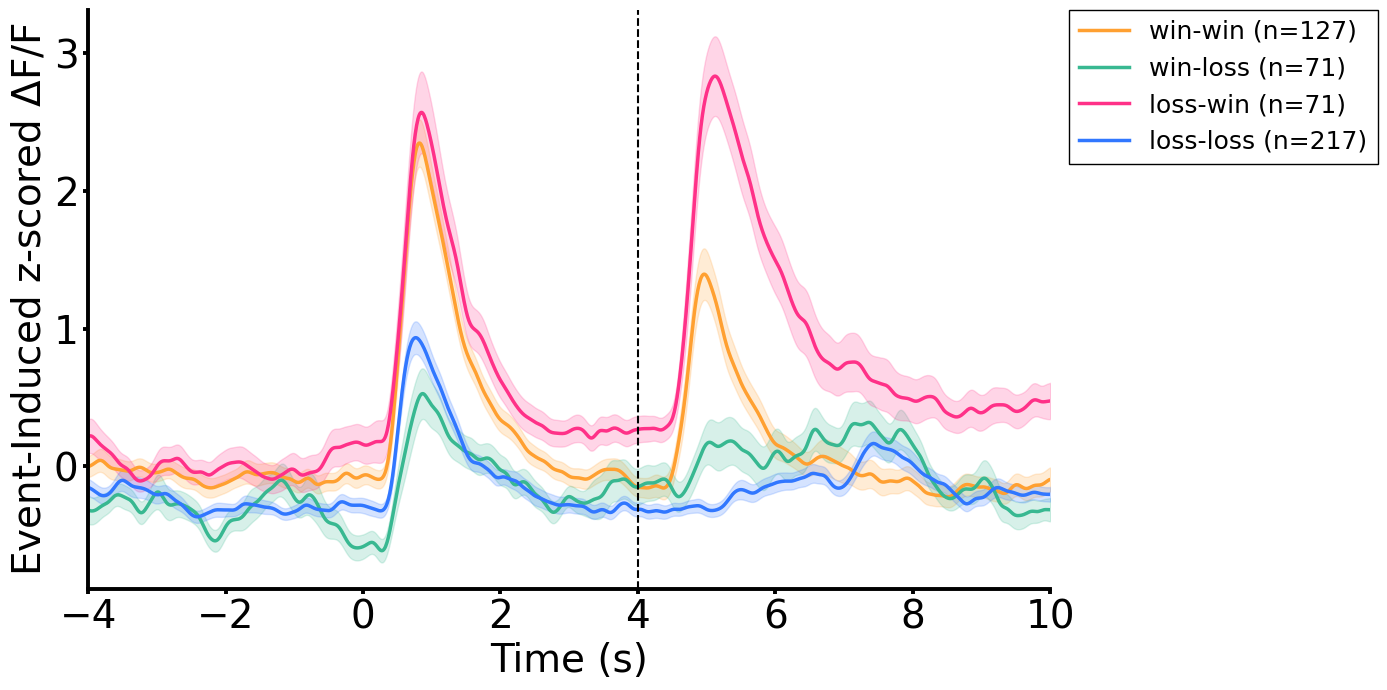

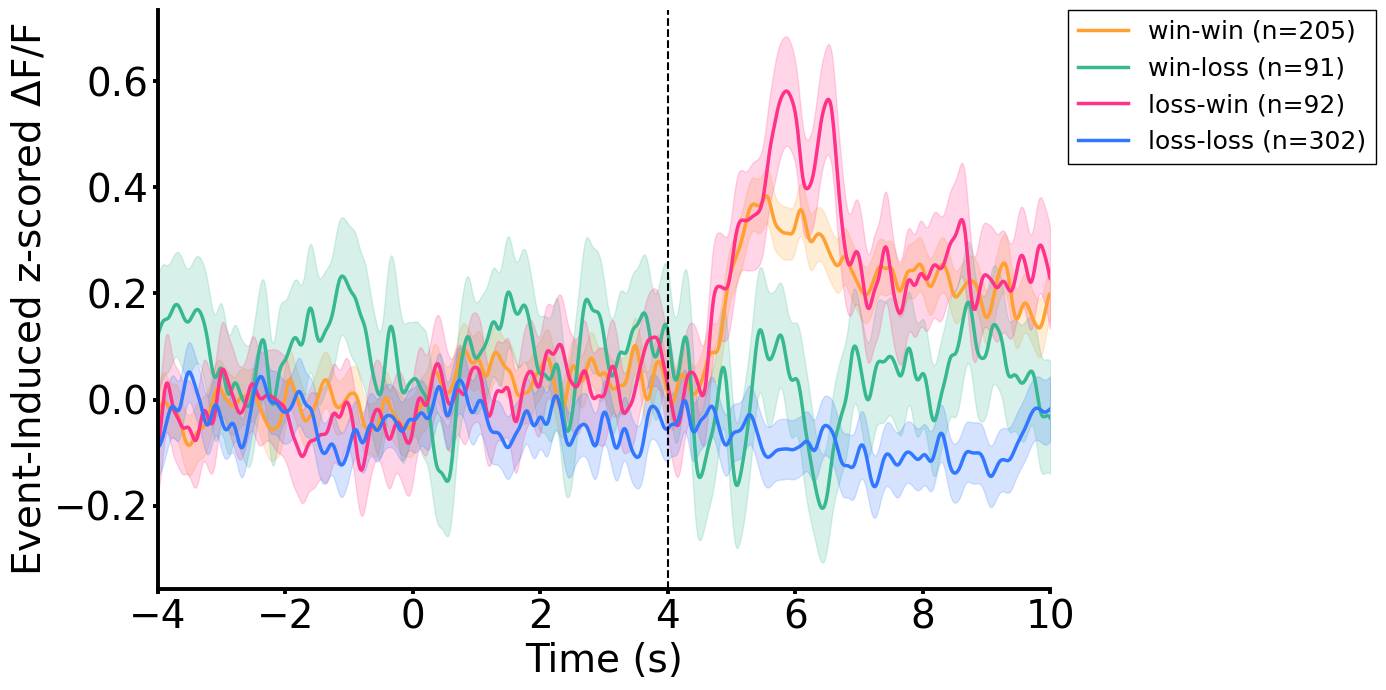

In [15]:
for region in ['NAc', 'mPFC']:
    plot_consecutive_outcome_psth(
        tone_consecutive_exploded,
        region=region,
        align_to='pe',
        event_line_at=4.0,
        title=None,
        figsize=(14,7),
        background_color='none',
        # font_size=26,
        sequence_colors=['#ffa031', "#38b891"  ,'#ff3188', "#3177ff",],
        axis_line_width=2.8,
        label_font_size=28,
        tick_font_size=28,
        legend_font_size=18,


    )

# CONSECUTIVE_OUTCOME_COLORS = {
#     'win-win':  '#1b9e77',
#     'win-loss': '#d95f02',
#     'loss-win': '#7570b3',
#     'loss-loss':'#e7298a',
# }

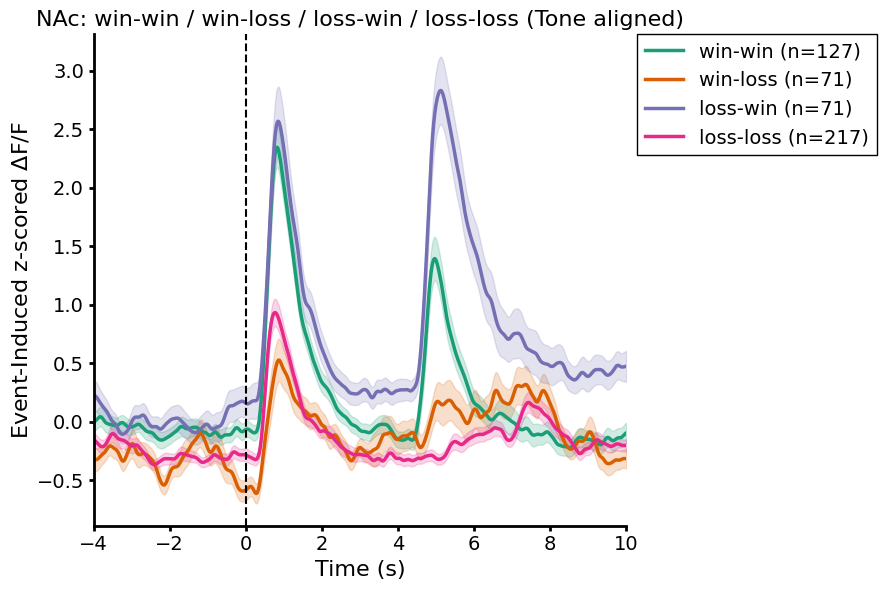

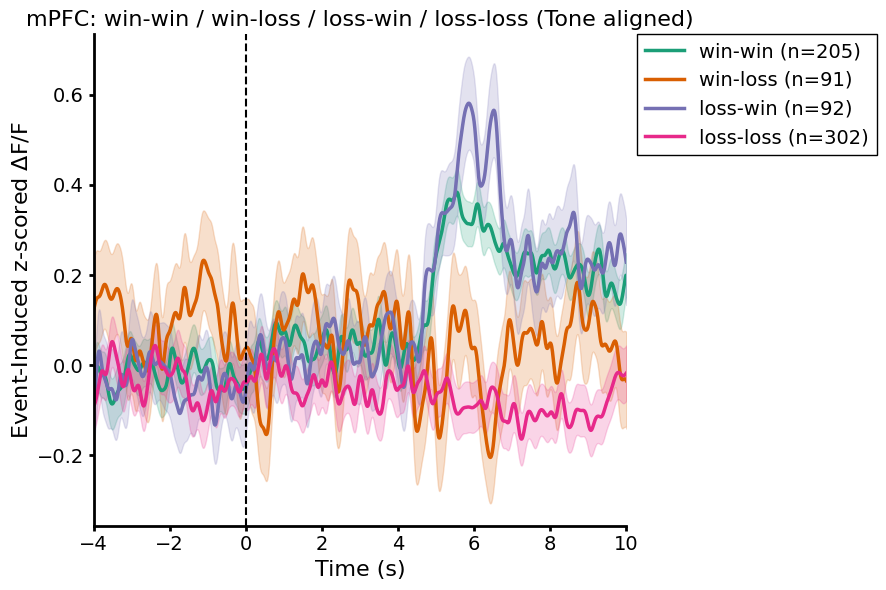

In [16]:
for region in ['NAc', 'mPFC']:
    plot_consecutive_outcome_psth(
        tone_consecutive_exploded,
        region=region,
        align_to='tone',
        event_line_at=0.0,
        title=f'{region}: win-win / win-loss / loss-win / loss-loss (Tone aligned)',
    )


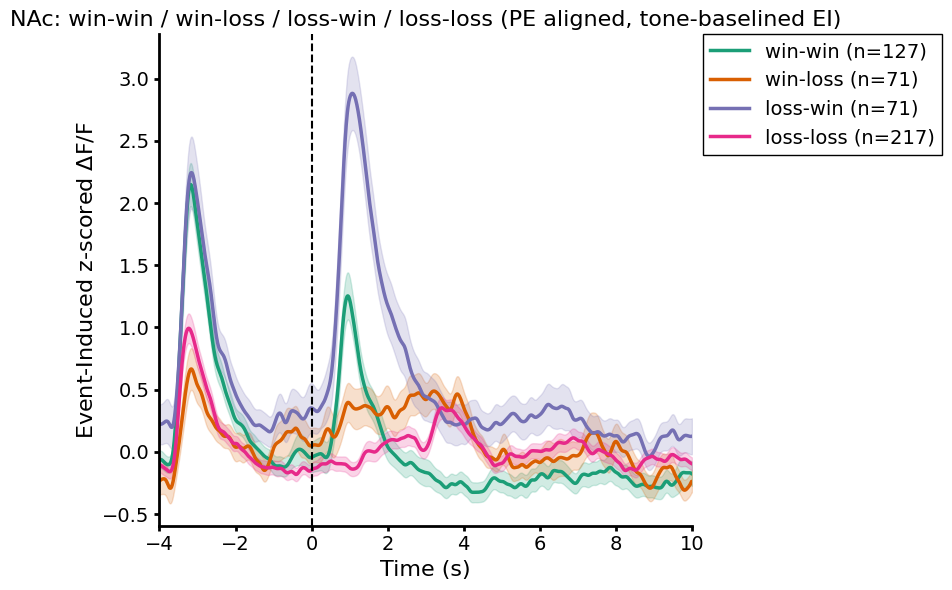

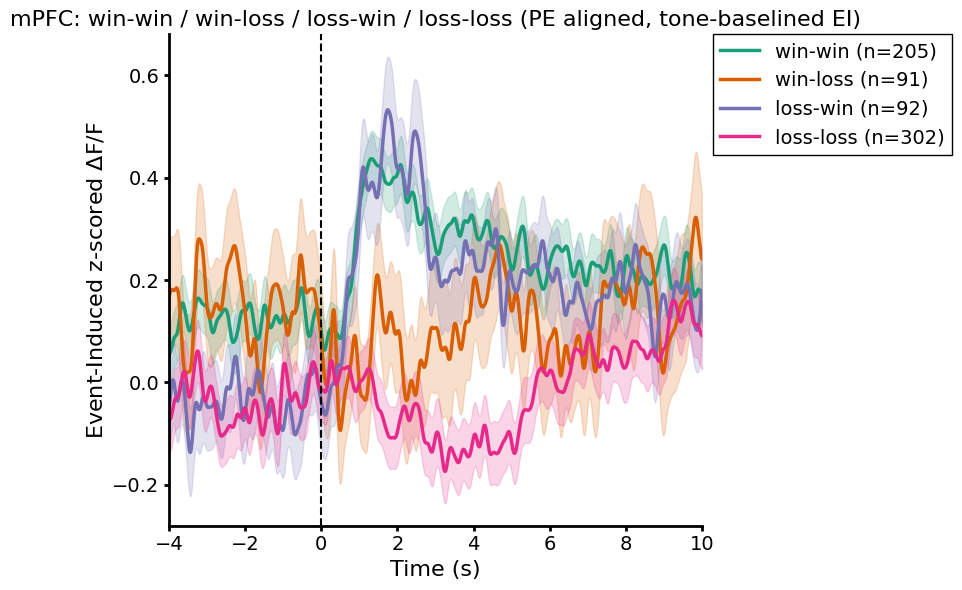

In [17]:
for region in ['NAc', 'mPFC']:
    plot_consecutive_outcome_psth(
        pe_consecutive_exploded,
        region=region,
        align_to='pe',
        time_window=(-4, 10),
        event_line_at=0.0,
        title=f'{region}: win-win / win-loss / loss-win / loss-loss (PE aligned, tone-baselined EI)',
    )


In [18]:
metrics = [
    'filtered_winner_array', 'HVL_PreComp', 'Pretrial_Time_Axis', 'Pretrial_Zscore',
    'Pretrial AUC', 'Pretrial Max Peak', 'Pretrial Time of Max Peak', 'Pretrial Mean Z-score'
]

pretrial_exploded = explode_event_traces(
    rc_exp.da_df,
    comp_col  = 'HVL_PreComp',
    time_col  = 'Pretrial_Time_Axis',
    trace_col = 'Pretrial_Zscore',
    array_cols=metrics
)



In [19]:
pretrial_exploded.head()

,subject_name,comp,time,trace,filtered_winner_array,HVL_PreComp,Pretrial_Time_Axis,Pretrial_Zscore,Pretrial AUC,Pretrial Max Peak,Pretrial Time of Max Peak,Pretrial Mean Z-score
0,nn5,0,"[-10.0, -9.990000000000236, -9.980000000000473...","[-0.6331469808622158, -0.6416844621474599, -0....",nn8,0.0,"[-10.0, -9.990000000000236, -9.980000000000473...","[-0.6331469808622158, -0.6416844621474599, -0....",-1.333687,1.007106,-3.42,-0.133708
1,nn5,0,"[-10.0, -9.990000000000236, -9.980000000000473...","[-0.612908859073835, -0.584517236745723, -0.55...",nn8,0.0,"[-10.0, -9.990000000000236, -9.980000000000473...","[-0.612908859073835, -0.584517236745723, -0.55...",0.662839,1.468597,-0.82,0.065832
2,nn5,0,"[-10.0, -9.990000000000236, -9.980000000000473...","[-0.05802353785014144, 0.014486839845256505, 0...",nn8,0.0,"[-10.0, -9.990000000000236, -9.980000000000473...","[-0.05802353785014144, 0.014486839845256505, 0...",3.436629,6.407753,-4.42,0.342966
3,nn5,0,"[-10.0, -9.990000000000236, -9.980000000000473...","[0.3345489519925748, 0.33488041980267524, 0.36...",nn8,0.0,"[-10.0, -9.990000000000236, -9.980000000000473...","[0.3345489519925748, 0.33488041980267524, 0.36...",11.679567,4.479581,-7.97,1.166766
4,nn5,0,"[-10.0, -9.990000000000236, -9.980000000000473...","[-0.32109386954153807, -0.3217502511750373, -0...",nn8,0.0,"[-10.0, -9.990000000000236, -9.980000000000473...","[-0.32109386954153807, -0.3217502511750373, -0...",-1.500504,1.028468,-7.69,-0.150144


In [20]:
# plot_psth_for_region(
#     exploded_df = pretrial_exploded,
#     region = 'NAc',
#     time_col    = 'time',
#     trace_col   = 'trace',
#     comp_col    = 'comp',
#     time_window = (-10,0),
#     labels      = ('Low comp','High comp')
# )

# plot_psth_for_region(
#     exploded_df = pretrial_exploded,
#     region = 'mPFC',
#     time_col    = 'time',
#     trace_col   = 'trace',
#     comp_col    = 'comp',
#     time_window = (-10,0),
#     labels      = ('Low comp','High comp')
# )

Pretrial Stats

In [21]:
def plot_comp_by_region(
    exploded_df,
    region:    str,         # 'NAc' or 'mPFC'
    metric:    str,         # e.g. 'Pretrial AUC'
    comp_col:  str = 'comp',
    plot_dots: bool = False
):
    """
    Bar plot of mean Ã‚Â± SEM for `metric`, comparing low vs high comp
    within the specified brain region, plus printed stats.
    If plot_dots=True, also scatter each individual value.
    """
    # map region Ã¢â€ â€™ prefix for subject_name
    prefix_map = {'NAc': 'n', 'mPFC': 'p'}
    if region not in prefix_map:
        raise ValueError(f"region must be one of {list(prefix_map)}")
    prefix = prefix_map[region]

    # filter to region
    df = exploded_df[exploded_df['subject_name'].str.startswith(prefix)]
    if df.empty:
        raise ValueError(f"No data for region {region}")

    # split into low/high comp
    groups = {
        0: df[df[comp_col] == 0][metric].dropna(),
        1: df[df[comp_col] == 1][metric].dropna()
    }

    # compute means & SEMs
    means = [g.mean() for g in (groups[0], groups[1])]
    sems  = [g.sem()  for g in (groups[0], groups[1])]

    # print group stats and t-test
    n0, n1 = len(groups[0]), len(groups[1])
    print(f"Low comp  (n={n0}): mean={means[0]:.3f}, SEM={sems[0]:.3f}")
    print(f"High comp (n={n1}): mean={means[1]:.3f}, SEM={sems[1]:.3f}")
    t_stat, p_val = ttest_ind(groups[0], groups[1], nan_policy='omit')
    print(f"T-test: t={t_stat:.3f}, p={p_val:.3f}")

    # plot bar chart
    labels = ['Low comp', 'High comp']
    colors = ['blue', 'orange']
    x = np.arange(2)

    fig, ax = plt.subplots(figsize=(6,4))
    ax.bar(x, means, yerr=sems, color=colors, capsize=5)

    # optionally scatter individual points
    if plot_dots:
        for xi, comp in enumerate((0, 1)):
            y = groups[comp]
            xs = np.random.normal(loc=xi, scale=0.05, size=len(y))
            ax.scatter(
                xs, y,
                facecolor=colors[comp],
                edgecolor='lightgrey',
                linewidth=0.8,
                alpha=0.8
            )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(metric)
    ax.set_title(f"{region}: {metric} by Competition Level")
    plt.tight_layout()
    plt.show()


Low comp  (n=294): mean=-1.509, SEM=0.269
High comp (n=41): mean=-0.689, SEM=0.690
T-test: t=-1.072, p=0.285


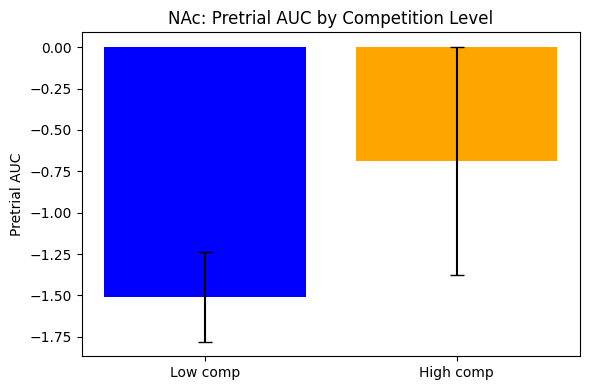

Low comp  (n=540): mean=-0.164, SEM=0.279
High comp (n=36): mean=-0.060, SEM=1.307
T-test: t=-0.092, p=0.927


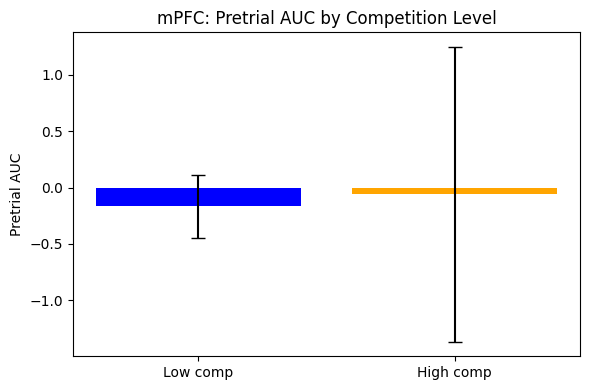

In [22]:
# Compare pretrial AUC in the NAc for low vs. high comp:
plot_comp_by_region(
    exploded_df=pretrial_exploded,
    region='NAc',
    metric='Pretrial AUC',
    plot_dots=False
)

# Compare pretrial AUC in the NAc for low vs. high comp:
plot_comp_by_region(
    exploded_df=pretrial_exploded,
    region='mPFC',
    metric='Pretrial AUC'
)


Low comp  (n=294): mean=1.878, SEM=0.080
High comp (n=41): mean=2.458, SEM=0.256
T-test: t=-2.483, p=0.014


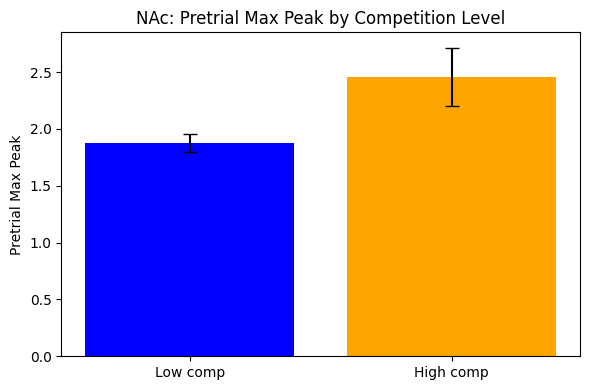

Low comp  (n=540): mean=1.381, SEM=0.037
High comp (n=36): mean=1.444, SEM=0.168
T-test: t=-0.420, p=0.674


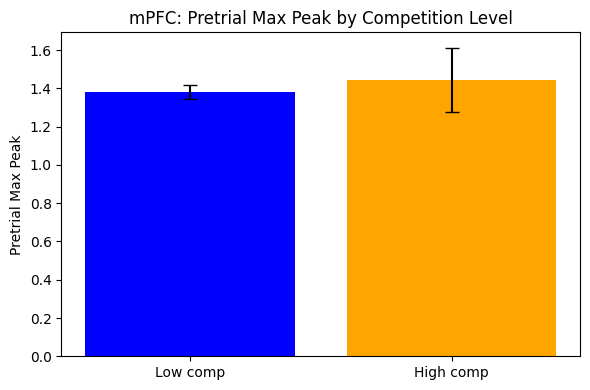

In [23]:
# Compare pretrial AUC in the NAc for low vs. high comp:
plot_comp_by_region(
    exploded_df=pretrial_exploded,
    region='NAc',
    metric='Pretrial Max Peak',
    plot_dots=False
)

# Compare pretrial AUC in the NAc for low vs. high comp:
plot_comp_by_region(
    exploded_df=pretrial_exploded,
    region='mPFC',
    metric='Pretrial Max Peak'
)


Low comp  (n=294): mean=-5.143, SEM=0.179
High comp (n=41): mean=-4.695, SEM=0.442
T-test: t=-0.882, p=0.379


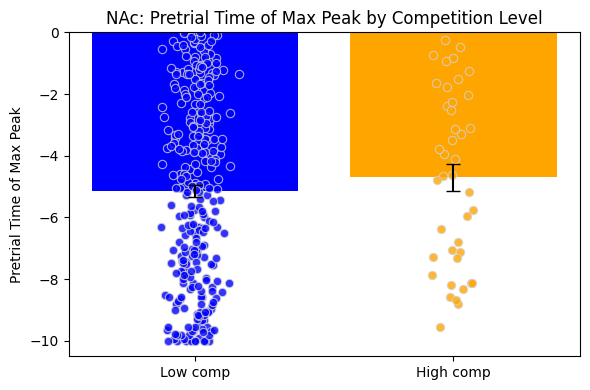

Low comp  (n=540): mean=-5.164, SEM=0.136
High comp (n=36): mean=-4.544, SEM=0.542
T-test: t=-1.136, p=0.257


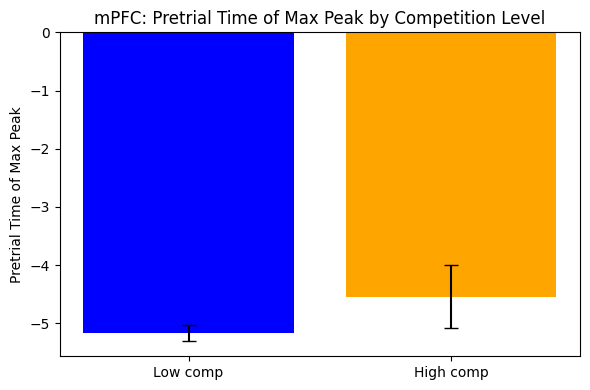

In [24]:
# Compare pretrial AUC in the NAc for low vs. high comp:
plot_comp_by_region(
    exploded_df=pretrial_exploded,
    region='NAc',
    metric='Pretrial Time of Max Peak',
    plot_dots=True
)

# Compare pretrial AUC in the NAc for low vs. high comp:
plot_comp_by_region(
    exploded_df=pretrial_exploded,
    region='mPFC',
    metric='Pretrial Time of Max Peak'
)


## Trial HvL regardless of Win vs. Loss

In [25]:
metrics = [
    'filtered_winner_array', 'HVL_Comp', 'Tone_Time_Axis', 'Tone_Zscore',
    'PE_Time_Axis', 'PE_Zscore', 
    'Tone AUC', 'Tone Max Peak', 'Tone Time of Max Peak', 'Tone Mean Z-score',
    'PE AUC', 'PE Max Peak', 'PE Time of Max Peak', 'PE Mean Z-score',
]

trial_exploded = explode_event_traces(
    rc_exp.da_df,
    comp_col  = 'HVL_Comp',
    time_col  = 'Tone_Time_Axis',
    trace_col = 'Tone_Zscore',
    array_cols=metrics
)


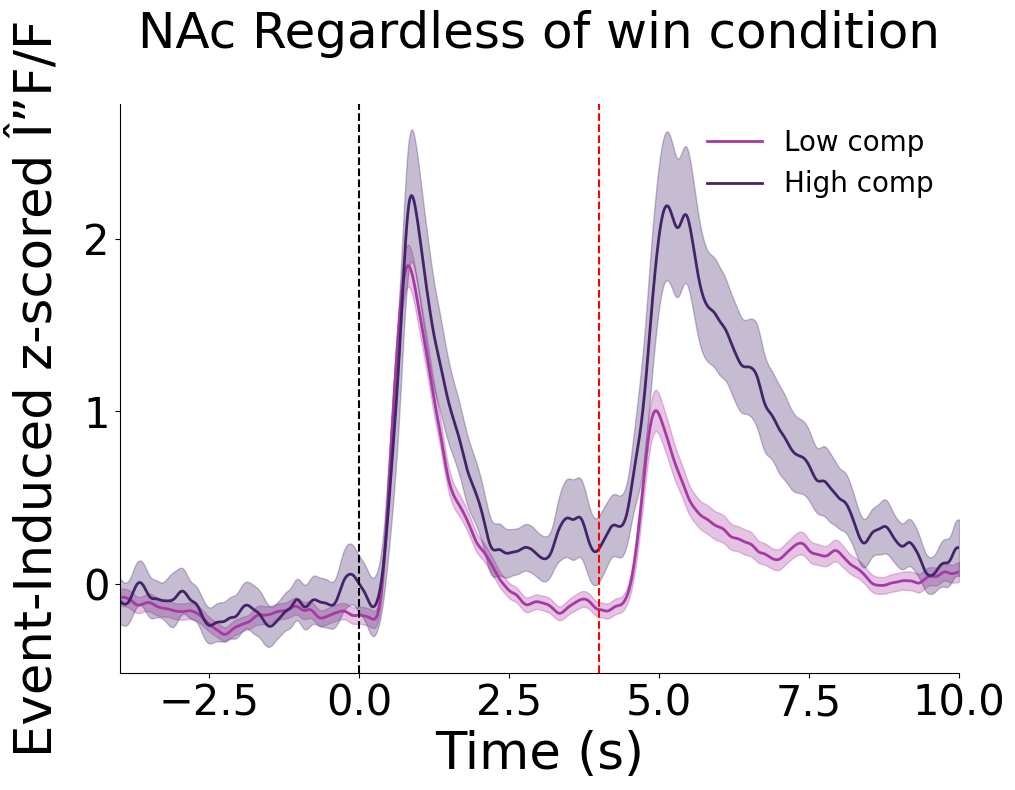

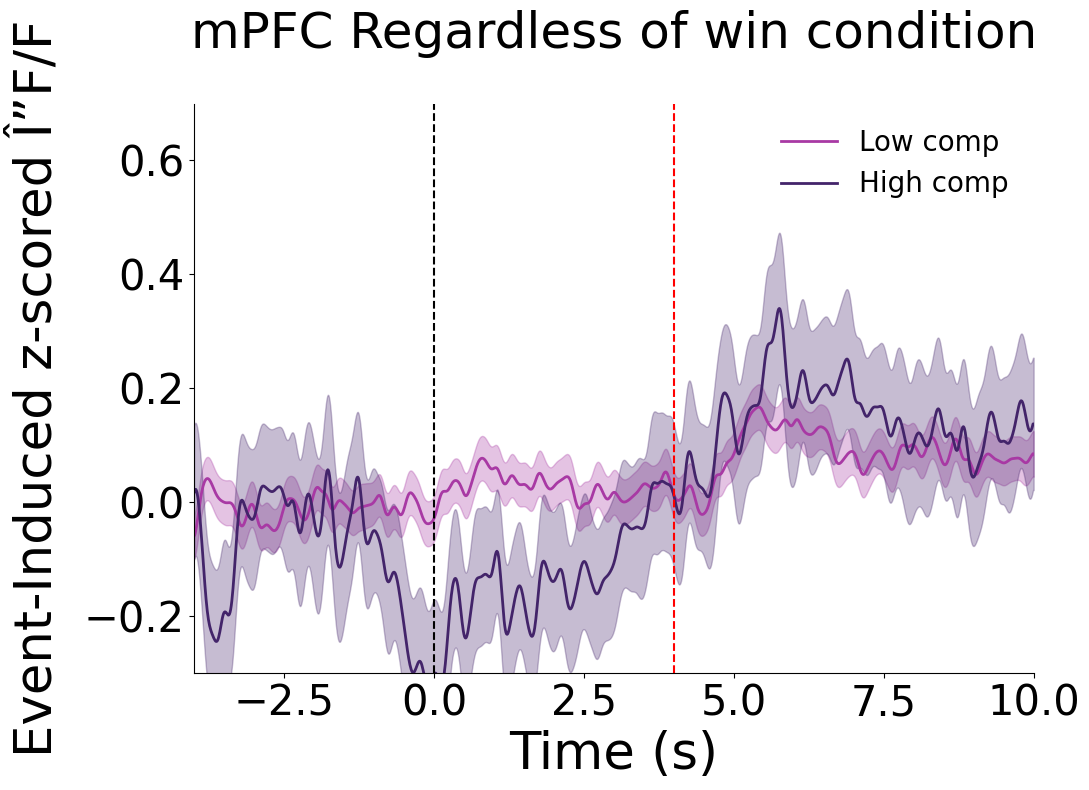

In [26]:
plot_psth_for_region(
    exploded_df = trial_exploded,
    region = 'NAc',
    time_col    = 'time',
    trace_col   = 'trace',
    comp_col    = 'comp',
    time_window = (-4,10),
    labels      = ('Low comp','High comp'),
    figsize=(11,8),
    title = 'NAc Regardless of win condition'
)

plot_psth_for_region(
    exploded_df = trial_exploded,
    region = 'mPFC',
    time_col    = 'time',
    trace_col   = 'trace',
    comp_col    = 'comp',
    time_window = (-4,10),
    labels      = ('Low comp','High comp'),
    figsize=(11,8),
    ylims= (-0.3,0.7),
    title = 'mPFC Regardless of win condition'
)

Low comp  (n=283): mean=2.798, SEM=0.122
High comp (n=42): mean=3.267, SEM=0.368
T-test: t=-1.349, p=0.178


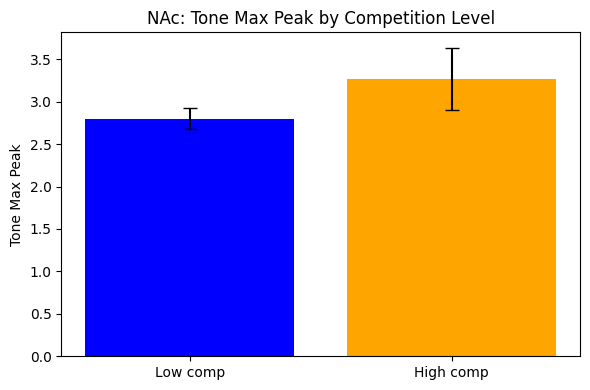

Low comp  (n=283): mean=2.395, SEM=0.125
High comp (n=42): mean=4.062, SEM=0.410
T-test: t=-4.623, p=0.000


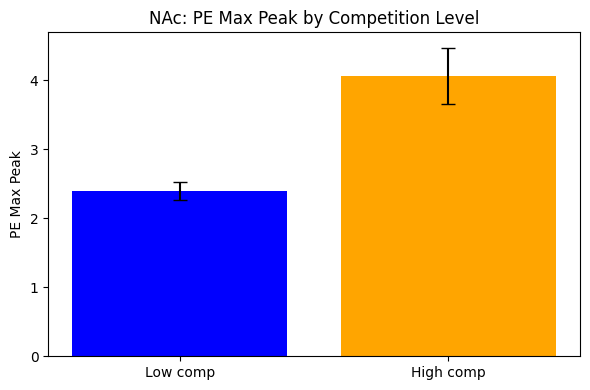

In [27]:
plot_comp_by_region(
    exploded_df=trial_exploded,
    region='NAc',
    metric='Tone Max Peak'
)

plot_comp_by_region(
    exploded_df=trial_exploded,
    region='NAc',
    metric='PE Max Peak'
)

Low comp  (n=283): mean=1.338, SEM=0.195
High comp (n=42): mean=2.424, SEM=0.660
T-test: t=-1.918, p=0.056


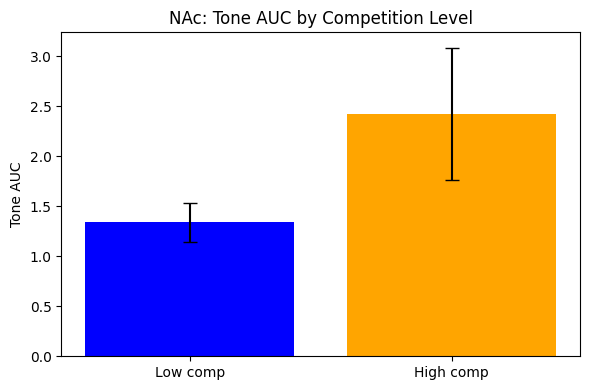

Low comp  (n=283): mean=1.328, SEM=0.215
High comp (n=42): mean=3.965, SEM=0.768
T-test: t=-4.180, p=0.000


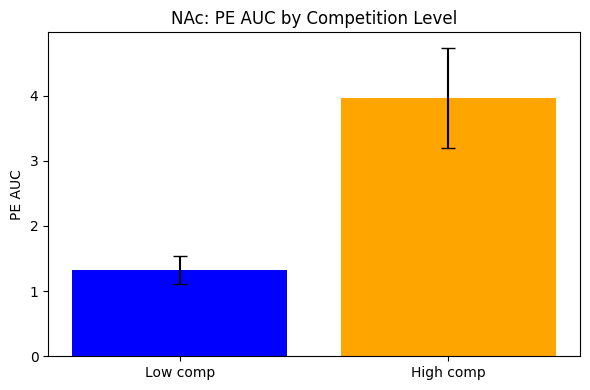

In [28]:
plot_comp_by_region(
    exploded_df=trial_exploded,
    region='NAc',
    metric='Tone AUC'
)

plot_comp_by_region(
    exploded_df=trial_exploded,
    region='NAc',
    metric='PE AUC'
)

Low comp  (n=513): mean=0.112, SEM=0.127
High comp (n=52): mean=-0.512, SEM=0.384
T-test: t=1.494, p=0.136


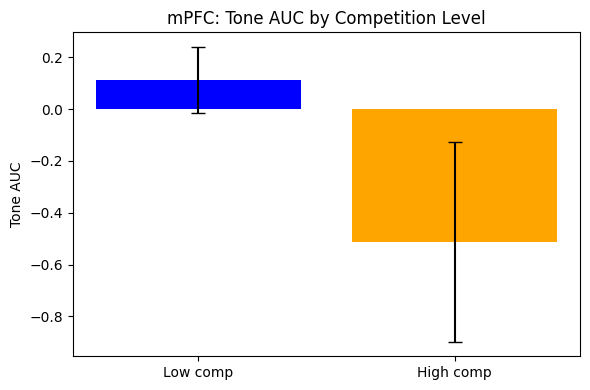

Low comp  (n=513): mean=0.606, SEM=0.144
High comp (n=52): mean=0.990, SEM=0.345
T-test: t=-0.822, p=0.411


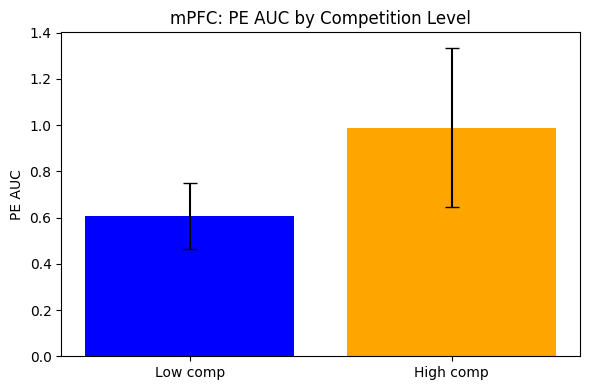

In [29]:
plot_comp_by_region(
    exploded_df=trial_exploded,
    region='mPFC',
    metric='Tone AUC'
)

plot_comp_by_region(
    exploded_df=trial_exploded,
    region='mPFC',
    metric='PE AUC'
)

## Splitting by win v loss and then looking at high vs. low comp

In [30]:
rc_exp.split_by_outcome()

In [31]:
# rc_exp.split_by_winner()

In [32]:
metrics = [
    'filtered_winner_array', 'HVL_Comp', 'Tone_Time_Axis', 'Tone_Zscore',
    'PE_Time_Axis', 'PE_Zscore', 
    'Tone AUC', 'Tone Max Peak', 'Tone Time of Max Peak', 'Tone Mean Z-score',
    'PE AUC', 'PE Max Peak', 'PE Time of Max Peak', 'PE Mean Z-score',
]

win_exploded = explode_event_traces(
    rc_exp.winner_df,
    comp_col  = 'HVL_Comp',
    time_col  = 'Tone_Time_Axis',
    trace_col = 'Tone_Zscore',
    array_cols=metrics
)


In [33]:
metrics = [
    'filtered_winner_array', 'HVL_Comp', 'Tone_Time_Axis', 'Tone_Zscore',
    'PE_Time_Axis', 'PE_Zscore', 
    'Tone AUC', 'Tone Max Peak', 'Tone Time of Max Peak', 'Tone Mean Z-score',
    'PE AUC', 'PE Max Peak', 'PE Time of Max Peak', 'PE Mean Z-score',
]

loss_exploded = explode_event_traces(
    rc_exp.loser_df,
    comp_col  = 'HVL_Comp',
    time_col  = 'Tone_Time_Axis',
    trace_col = 'Tone_Zscore',
    array_cols=metrics
)


In [34]:
tie_exploded = explode_event_traces_ties(
    rc_exp.tie_df,
    comp_col  = 'HVL_Comp',
    time_col  = 'Tone_Time_Axis',
    trace_col = 'Tone_Zscore',
    array_cols=metrics
)

In [35]:
rc_exp.tie_df.columns

Index(['subject_name', 'file name', 'trial', 'filtered_sound_cues',
       'filtered_port_entries', 'filtered_port_entry_offset',
       'filtered_winner_array', 'HVL_PreComp', 'HVL_Comp',
       'first_PE_after_sound_cue', 'Tone_Time_Axis', 'Tone_Zscore',
       'PE_Time_Axis', 'PE_Zscore', 'Pretrial_Time_Axis', 'Pretrial_Zscore',
       'Tone AUC', 'Tone Max Peak', 'Tone Time of Max Peak',
       'Tone Mean Z-score', 'PE AUC', 'PE Max Peak', 'PE Time of Max Peak',
       'PE Mean Z-score', 'Pretrial AUC', 'Pretrial Max Peak',
       'Pretrial Time of Max Peak', 'Pretrial Mean Z-score'],
      dtype='object')

In [36]:
tie_exploded.columns

RangeIndex(start=0, stop=0, step=1)

In [37]:
win_exploded.columns

Index(['subject_name', 'comp', 'time', 'trace', 'filtered_winner_array',
       'HVL_Comp', 'Tone_Time_Axis', 'Tone_Zscore', 'PE_Time_Axis',
       'PE_Zscore', 'Tone AUC', 'Tone Max Peak', 'Tone Time of Max Peak',
       'Tone Mean Z-score', 'PE AUC', 'PE Max Peak', 'PE Time of Max Peak',
       'PE Mean Z-score'],
      dtype='object')

C:\Users\alber\AppData\Local\Temp\ipykernel_1488\859240437.py:65: RuntimeWarning: Mean of empty slice
  mean_trace = np.nanmean(M, axis=0)
c:\Users\alber\anaconda3\envs\photometry\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


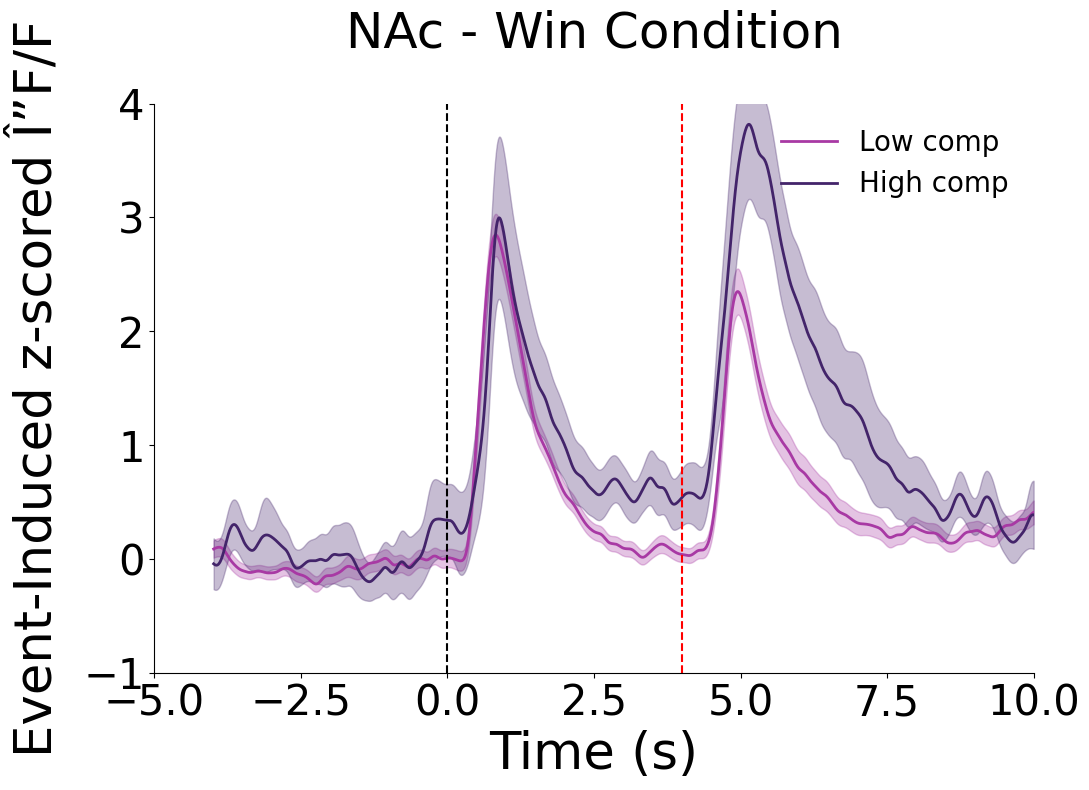

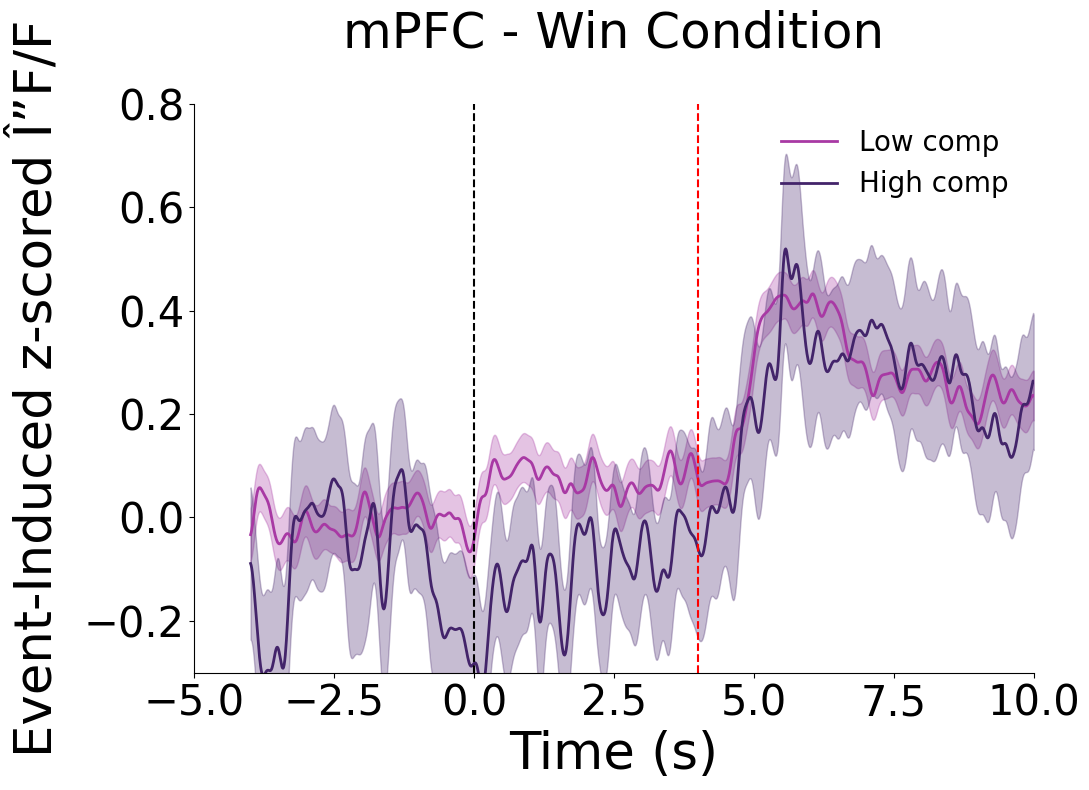

In [38]:
plot_psth_for_region(
    exploded_df = win_exploded,
    region = 'NAc',
    time_col    = 'time',
    trace_col   = 'trace',
    comp_col    = 'comp',
    time_window = (-5,10),
    labels      = ('Low comp','High comp'),
    ylims= (-1,4),
    title = 'NAc - Win Condition'
)

plot_psth_for_region(
    exploded_df = win_exploded,
    region = 'mPFC',
    time_col    = 'time',
    trace_col   = 'trace',
    comp_col    = 'comp',
    time_window = (-5,10),
    labels      = ('Low comp','High comp'),
    ylims= (-0.3,.8),
    title = 'mPFC - Win Condition'
)

C:\Users\alber\AppData\Local\Temp\ipykernel_1488\859240437.py:65: RuntimeWarning: Mean of empty slice
  mean_trace = np.nanmean(M, axis=0)


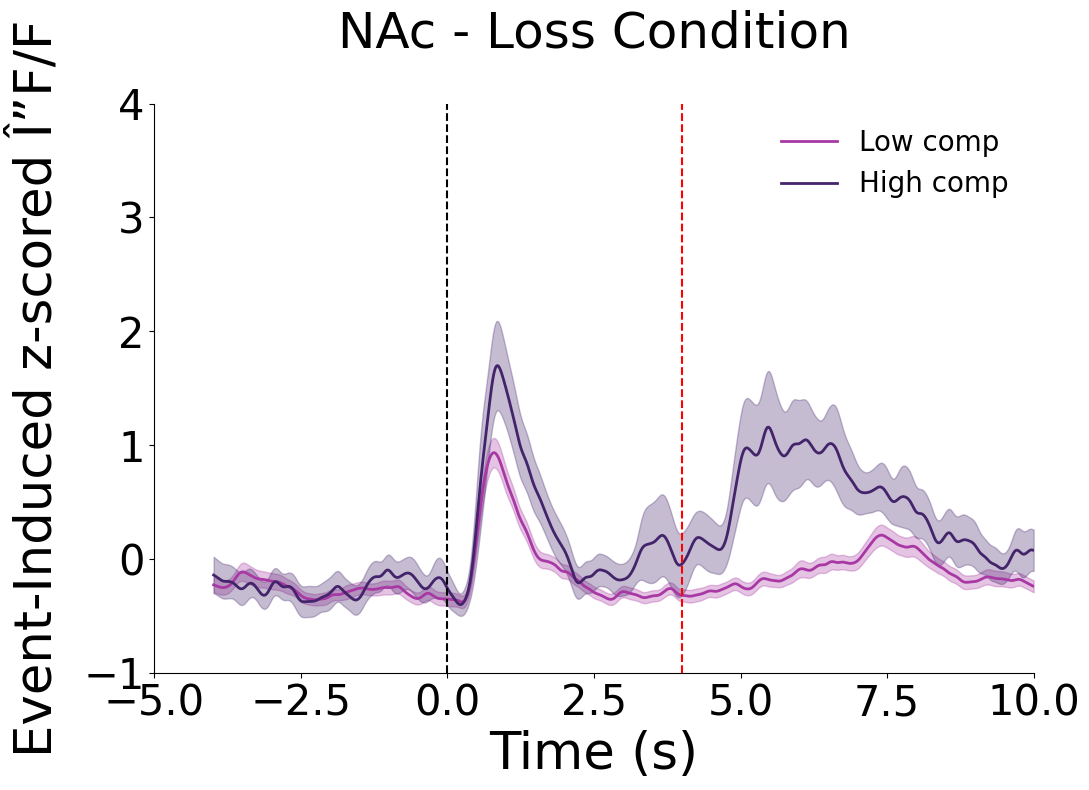

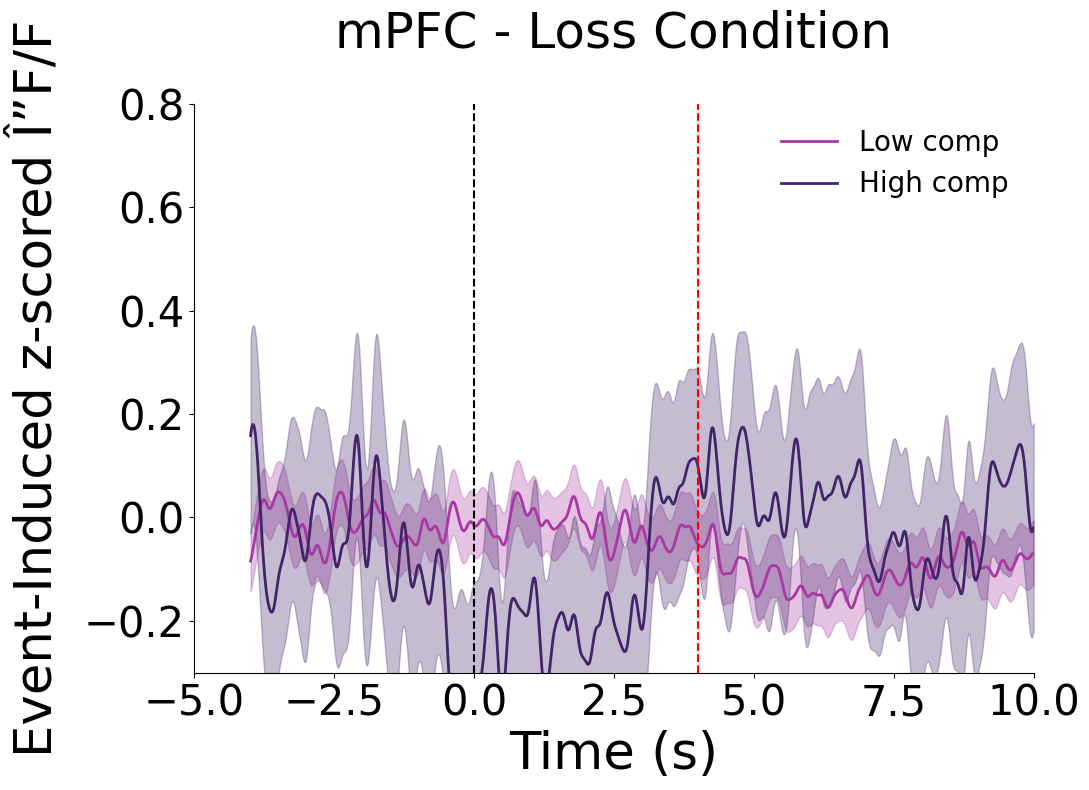

In [39]:
plot_psth_for_region(
    exploded_df = loss_exploded,
    region = 'NAc',
    time_col    = 'time',
    trace_col   = 'trace',
    comp_col    = 'comp',
    time_window = (-5,10),
    labels      = ('Low comp','High comp'),
    ylims= (-1,4),
    title = 'NAc - Loss Condition'
)

plot_psth_for_region(
    exploded_df = loss_exploded,
    region = 'mPFC',
    time_col    = 'time',
    trace_col   = 'trace',
    comp_col    = 'comp',
    time_window = (-5,10),
    labels      = ('Low comp','High comp'),
    ylims= (-0.3,.8),
    title = 'mPFC - Loss Condition'
)

In [40]:
def plot_psth_for_region_ties(
    exploded_df: pd.DataFrame,
    region:      str   = 'NAc',            # 'NAc' or 'mPFC'
    time_col:    str   = 'time',
    trace_col:   str   = 'trace',
    comp_col:    str   = 'comp',           # numeric 0/1 or mixed
    *,
    # tie detection options:
    outcome_col: str | None = None,        # e.g., 'outcome' with values {'low','high','tie'}
    tie_mask_col: str | None = None,       # boolean list per event marking ties
    tie_tokens:   tuple = ("T","t","tie","Tie","TIE"),
    ties_only:    bool  = False,
    # visuals:
    time_window: tuple = (-5.0, 10.0),
    line_at:     float = 4.0,
    colors:      tuple = ('#a839a4', '#43246a'),   # low, high
    labels:      tuple = ('Low comp', 'High comp'),
    tie_color:   str   = '#888888',
    tie_label:   str   = 'Tie',
    figsize:     tuple = (11,8),
    title:       str   = None,
    ylims:       tuple = None
):
    """
    Plot mean Ã‚Â± SEM PSTH for NAc or mPFC, supporting Low/High/Tie.
    If `outcome_col` is provided, it is used directly ('low','high','tie').
    Else, ties are inferred from `tie_mask_col` or from `comp_col` values.
    """
    # region filter
    prefix_map = {'NAc': 'n', 'mPFC': 'p'}
    if region not in prefix_map:
        raise ValueError(f"region must be one of {list(prefix_map)}")
    prefix = prefix_map[region]
    sub = exploded_df[exploded_df['subject_name'].str.startswith(prefix)]
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    if sub.empty:
        ax.set_title(f"No data for {region}", fontsize=36); ax.axis('off'); plt.show(); return

    # ---------- build a per-row condition label: 'low' | 'high' | 'tie' ----------
    def _label_row(row, idx=None):
        # priority 1: explicit outcome col
        if outcome_col and outcome_col in row and pd.notna(row[outcome_col]):
            val = str(row[outcome_col]).strip().lower()
            if val in ('low','high','tie'):
                return val

        # priority 2: tie mask column (boolean list aligned with events)
        if tie_mask_col and tie_mask_col in row:
            mask = row[tie_mask_col] if isinstance(row[tie_mask_col], list) else []
            if idx is not None and idx < len(mask):
                if bool(mask[idx]): return 'tie'

        # fallback: infer from comp_col
        c = row.get(comp_col, np.nan)
        # eventwise rows already hold scalar comp; if not, try to index
        if isinstance(c, (list, np.ndarray)) and idx is not None and idx < len(c):
            c = c[idx]
        # tie from token or NaN
        if (isinstance(c, str) and c.strip() in tie_tokens) or pd.isna(c):
            return 'tie'
        # numeric low/high
        try:
            v = int(c)
            return 'low' if v == 0 else ('high' if v == 1 else 'tie')
        except Exception:
            return 'tie'

    # if exploded_df is truly "exploded", each row is one event; no per-event idx.
    # We still call _label_row(row) without idx to classify the row.
    cond = sub.apply(lambda r: _label_row(r, None), axis=1)
    sub = sub.assign(_cond=cond)

    # ties_only filter
    if ties_only:
        sub = sub[sub['_cond'] == 'tie']
        cond_order = [('tie', tie_label, tie_color)]
    else:
        cond_order = [
            ('low',  labels[0], colors[0]),
            ('high', labels[1], colors[1]),
            ('tie',  tie_label, tie_color),
        ]

    # ---------- common dt & axis ----------
    all_dts = [np.min(np.diff(t)) for t in sub[time_col] if getattr(t, "size", 0) > 1]
    if not all_dts:
        ax.set_title("No valid ÃŽâ€t found in time axes!", fontsize=24); ax.axis('off'); plt.show(); return
    dt = min(all_dts)
    t0, t1 = time_window
    common_t = np.arange(t0, t1 + dt/2, dt)

    # ---------- plot per condition ----------
    any_plotted = False
    for key, lbl, col in cond_order:
        grp = sub[sub['_cond'] == key]
        if grp.empty:
            continue
        mats = []
        for _, row in grp.iterrows():
            t_evt = row[time_col]; z_evt = row[trace_col]
            if getattr(t_evt, "size", 0) < 2 or getattr(z_evt, "size", 0) < 2:
                continue
            z_i = np.interp(common_t, t_evt, z_evt, left=np.nan, right=np.nan)
            mats.append(z_i)
        if not mats:
            continue
        M = np.vstack(mats)
        mean_trace = np.nanmean(M, axis=0)
        sem_trace  = np.nanstd(M, axis=0, ddof=1) / np.sqrt(M.shape[0])
        ax.plot(common_t, mean_trace, lw=2, label=lbl, color=col)
        ax.fill_between(common_t, mean_trace - sem_trace, mean_trace + sem_trace, alpha=0.3, color=col)
        any_plotted = True

    # ---------- styling ----------
    if not any_plotted:
        ax.set_title("No valid events to plot.", fontsize=24); ax.axis('off'); plt.show(); return

    ax.axvline(0, color='k', ls='--', lw=1.5)
    ax.axvline(line_at, color='red', ls='--', lw=1.5)
    ax.set_xlim(time_window)
    if ylims is not None:
        ax.set_ylim(ylims)

    ttl = title if title is not None else f"{region} PSTH: Low vs High" + (" (Ties only)" if ties_only else " (+ Ties)")
    ax.set_title(ttl, fontsize=32, pad=30)
    ax.set_xlabel("Time (s)", fontsize=30)
    ax.set_ylabel("Event-Induced z-scored ÃŽâ€F/F", fontsize=30, labelpad=12)
    ax.tick_params(axis='both', which='major', labelsize=24)
    ax.legend(frameon=False, fontsize=18, loc='upper right')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.show()


In [41]:
plot_psth_for_region_ties(
    exploded_df = tie_exploded,
    region = 'NAc',
    time_col    = 'time',
    ties_only=True,
    trace_col   = 'trace',
    comp_col    = 'comp',
    time_window = (-5,10),
    labels      = ('Low comp','High comp'),
    ylims= (-1,4),
    title = 'NAc - Tie Condition'
)

plot_psth_for_region_ties(
    exploded_df = tie_exploded,
    region = 'mPFC',
    time_col    = 'time',
    ties_only=True,
    trace_col   = 'trace',
    comp_col    = 'comp',
    time_window = (-5,10),
    labels      = ('Low comp','High comp'),
    ylims= (-0.6,.8),
    title = 'mPFC - Tie Condition'
)

KeyError: 'subject_name'

In [ ]:
n_ties = len(rc_exp.tie_df)
print(f"Total tie events: {n_ties}")


Total tie events: 70


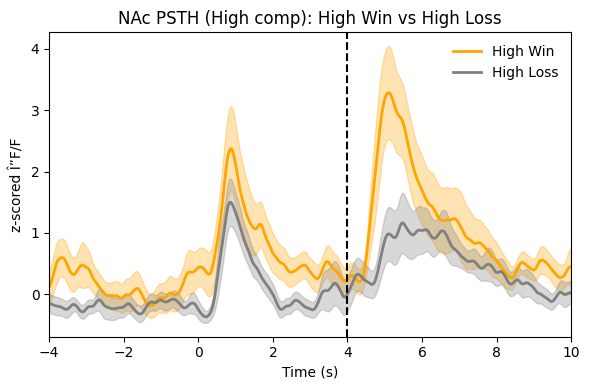

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_high_win_loss_psth(
    win_df:      pd.DataFrame,
    loss_df:     pd.DataFrame,
    region:      str      = 'NAc',          # 'NAc' or 'mPFC'
    time_col:    str      = 'time',
    trace_col:   str      = 'trace',
    comp_col:    str      = 'comp',
    time_window: tuple    = (-4.0, 10.0),
    line_at:     float    = 4.0,
    colors:      tuple    = ('orange', 'grey'),
    labels:      tuple    = ('High Win', 'High Loss'),
    figsize:     tuple    = (6,4)
):
    """
    Plot meanÃ‚Â±SEM PSTH for just high-comp wins vs losses in a single region.
    
    Parameters
    ----------
    win_df, loss_df : DataFrame
        Exploded-event DataFrames for win and loss trials.
    region : {'NAc','mPFC'}
        Which region to plot (filters by subject_name prefix).
    time_col, trace_col : str
        Column names holding per-event time & trace arrays.
    comp_col : str
        Column name for competition label (1=high,0=low).
    time_window : (start,end)
        Time range for interpolation & plotting.
    line_at : float
        Vertical marker (e.g. tone onset).
    colors : (win_color, loss_color)
    labels : (win_label, loss_label)
    figsize : figure size
    """
    # 1) Region Ã¢â€ â€™ prefix
    prefix_map = {'NAc':'n', 'mPFC':'p'}
    if region not in prefix_map:
        raise ValueError("region must be 'NAc' or 'mPFC'")
    pfx = prefix_map[region]

    # 2) filter for high-comp events in each DF
    win_sub  = win_df[  win_df['subject_name'].str.startswith(pfx) & (win_df[comp_col]==1) ]
    loss_sub = loss_df[ loss_df['subject_name'].str.startswith(pfx) & (loss_df[comp_col]==1) ]
    if win_sub.empty and loss_sub.empty:
        raise ValueError(f"No high-comp data for region {region}")

    # 3) determine smallest dt across both sets
    def _dts(dframe):
        return [np.min(np.diff(t)) for t in dframe[time_col] if getattr(t,'size',0)>1]
    all_dts = _dts(win_sub) + _dts(loss_sub)
    if not all_dts:
        raise RuntimeError("No valid ÃŽâ€t found!")
    dt = min(all_dts)

    # 4) build common time axis
    t0, t1 = time_window
    common_t = np.arange(t0, t1 + dt/2, dt)

    # 5) helper to compute mean & SEM
    def _mean_sem(subdf):
        mats = []
        for _, row in subdf.iterrows():
            t_evt = row[time_col]
            z_evt = row[trace_col]
            zi = np.interp(common_t, t_evt, z_evt,
                           left=np.nan, right=np.nan)
            mats.append(zi)
        M = np.vstack(mats) if mats else np.empty((0, len(common_t)))
        mean = np.nanmean(M, axis=0)
        sem  = np.nanstd(M, axis=0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0]>1 else np.zeros_like(common_t)
        return mean, sem

    win_mean,  win_sem  = _mean_sem(win_sub)
    loss_mean, loss_sem = _mean_sem(loss_sub)

    # 6) plot
    fig, ax = plt.subplots(1,1,figsize=figsize)
    ax.plot(common_t, win_mean,  color=colors[0], lw=2, label=labels[0])
    ax.fill_between(common_t,
                    win_mean-win_sem, win_mean+win_sem,
                    color=colors[0], alpha=0.3)

    ax.plot(common_t, loss_mean, color=colors[1], lw=2, label=labels[1])
    ax.fill_between(common_t,
                    loss_mean-loss_sem, loss_mean+loss_sem,
                    color=colors[1], alpha=0.3)

    ax.axvline(line_at, color='k', ls='--')
    ax.set_xlim(time_window)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("z-scored ÃŽâ€F/F")
    ax.set_title(f"{region} PSTH (High comp): {labels[0]} vs {labels[1]}")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

plot_high_win_loss_psth(
    win_df=win_exploded,
    loss_df=loss_exploded,
    region='NAc',
    time_col='time',
    trace_col='trace',
    comp_col='comp',
    time_window=(-4,10),
    line_at=4.0,
    colors=('orange','grey'),
    labels=('High Win','High Loss')
)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

def plot_win_loss_comp_by_region(
    win_df:     pd.DataFrame,
    loss_df:    pd.DataFrame,
    region:     str,             # 'NAc' or 'mPFC'
    metric:     str,             # e.g. 'Tone AUC'
    comp_col:   str = 'comp'
):
    """
    Bar plot (meanÃ‚Â±SEM) of `metric` for four groups:
      High Win, High Loss, Low Win, Low Loss
    within the given brain regionÃ¢â‚¬â€and prints pairwise t-tests:
      Ã¢â‚¬Â¢ High Win vs High Loss
      Ã¢â‚¬Â¢ Low Win  vs Low Loss
      Ã¢â‚¬Â¢ High Win vs Low Win
      Ã¢â‚¬Â¢ High Loss vs Low Loss
    """
    # 1) map region Ã¢â€ â€™ subject_name prefix
    prefix_map = {'NAc':'n', 'mPFC':'p'}
    if region not in prefix_map:
        raise ValueError(f"region must be one of {list(prefix_map)}")
    p = prefix_map[region]

    # 2) define the four (comp, outcome, label) combos
    combos = [
        (1, 'win',  'High Win'),
        (1, 'loss', 'High Loss'),
        (0, 'win',  'Low Win'),
        (0, 'loss', 'Low Loss'),
    ]

    # 3) collect series, means & sems
    series_dict = {}
    means, sems, labels = [], [], []
    for comp_val, outcome, label in combos:
        df = win_df if outcome == 'win' else loss_df
        sel = df[
            df['subject_name'].str.startswith(p) &
            (df[comp_col] == comp_val)
        ][metric].dropna()

        series_dict[(comp_val, outcome)] = sel
        means.append(sel.mean())
        sems.append(sel.sem())
        labels.append(label)

    # 4) print pairwise t-tests
    tests = [
        ((1,'win'),  (1,'loss'),  'High Win vs High Loss'),
        ((0,'win'),  (0,'loss'),  'Low Win  vs Low Loss'),
        ((1,'win'),  (0,'win'),   'High Win vs Low Win'),
        ((1,'loss'), (0,'loss'),  'High Loss vs Low Loss'),
    ]
    print(f"=== Stats for {region}, metric = {metric} ===")
    for k1, k2, name in tests:
        a = series_dict[k1]
        b = series_dict[k2]
        t_stat, p_val = ttest_ind(a, b, nan_policy='omit')
        print(f"{name}: nÃ¢â€šÂ={len(a)}, nÃ¢â€šâ€š={len(b)}, t={t_stat:.3f}, p={p_val:.3f}")
    print("="*40)

    # 5) plot
    x = np.arange(len(labels))
    colors = ['orange','orange','blue','blue']  # highÃ¢â€ â€™orange, lowÃ¢â€ â€™blue
    hatches = ['', '/', '', '/']               # loss bars hatched

    fig, ax = plt.subplots(figsize=(6,4))
    for xi, (m, s, c, h) in enumerate(zip(means, sems, colors, hatches)):
        ax.bar(xi, m, yerr=s,
               color=c, edgecolor='k',
               hatch=h, capsize=5)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(f"{region}: {metric} by Win/Loss & Comp")
    plt.tight_layout()
    plt.show()


=== Stats for NAc, metric = Tone AUC ===
High Win vs High Loss: nÃ¢â€šÂ=18, nÃ¢â€šâ€š=24, t=1.882, p=0.067
Low Win  vs Low Loss: nÃ¢â€šÂ=135, nÃ¢â€šâ€š=148, t=7.219, p=0.000
High Win vs Low Win: nÃ¢â€šÂ=18, nÃ¢â€šâ€š=135, t=0.364, p=0.717
High Loss vs Low Loss: nÃ¢â€šÂ=24, nÃ¢â€šâ€š=148, t=0.932, p=0.353


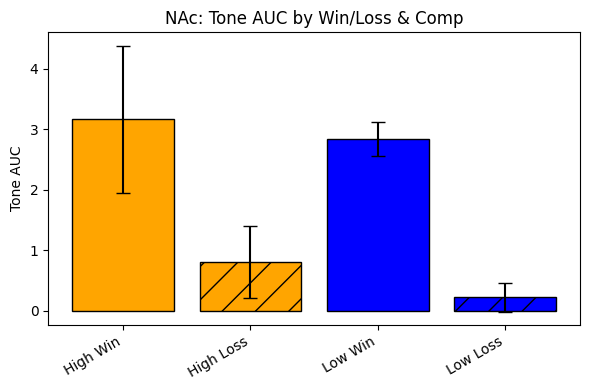

=== Stats for NAc, metric = Tone Max Peak ===
High Win vs High Loss: nÃ¢â€šÂ=18, nÃ¢â€šâ€š=24, t=0.722, p=0.474
Low Win  vs Low Loss: nÃ¢â€šÂ=135, nÃ¢â€šâ€š=148, t=7.473, p=0.000
High Win vs Low Win: nÃ¢â€šÂ=18, nÃ¢â€šâ€š=135, t=-0.890, p=0.375
High Loss vs Low Loss: nÃ¢â€šÂ=24, nÃ¢â€šâ€š=148, t=1.776, p=0.078


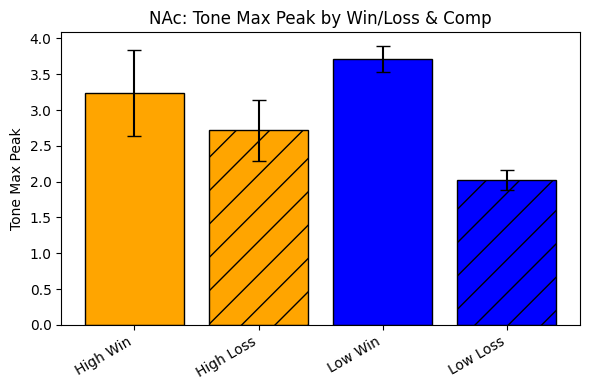

In [ ]:
plot_win_loss_comp_by_region(
    win_df=win_exploded,
    loss_df=loss_exploded,
    region='NAc',
    metric='Tone AUC'
)

plot_win_loss_comp_by_region(
    win_df=win_exploded,
    loss_df=loss_exploded,
    region='NAc',
    metric='Tone Max Peak'
)

=== Stats for NAc, metric = PE AUC ===
High Win vs High Loss: nÃ¢â€šÂ=18, nÃ¢â€šâ€š=24, t=1.128, p=0.266
Low Win  vs Low Loss: nÃ¢â€šÂ=135, nÃ¢â€šâ€š=148, t=4.787, p=0.000
High Win vs Low Win: nÃ¢â€šÂ=18, nÃ¢â€šâ€š=135, t=1.911, p=0.058


High Loss vs Low Loss: nÃ¢â€šÂ=24, nÃ¢â€šâ€š=148, t=3.662, p=0.000


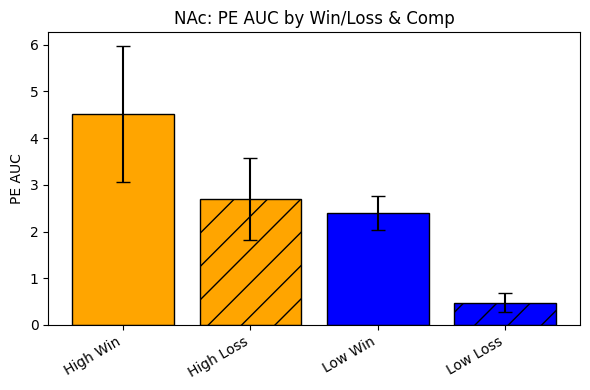

=== Stats for NAc, metric = PE Max Peak ===
High Win vs High Loss: nÃ¢â€šÂ=18, nÃ¢â€šâ€š=24, t=0.804, p=0.426
Low Win  vs Low Loss: nÃ¢â€šÂ=135, nÃ¢â€šâ€š=148, t=6.433, p=0.000
High Win vs Low Win: nÃ¢â€šÂ=18, nÃ¢â€šâ€š=135, t=1.596, p=0.112
High Loss vs Low Loss: nÃ¢â€šÂ=24, nÃ¢â€šâ€š=148, t=4.948, p=0.000


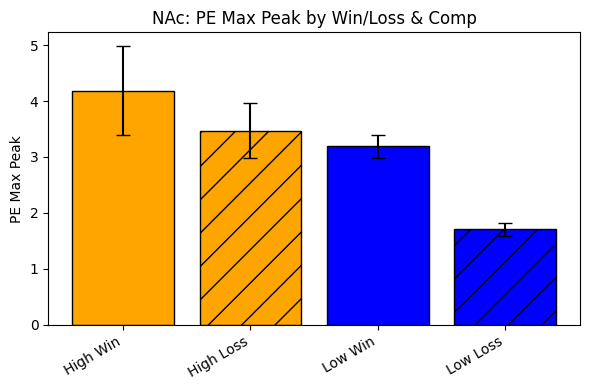

In [ ]:
plot_win_loss_comp_by_region(
    win_df=win_exploded,
    loss_df=loss_exploded,
    region='NAc',
    metric='PE AUC'
)

plot_win_loss_comp_by_region(
    win_df=win_exploded,
    loss_df=loss_exploded,
    region='NAc',
    metric='PE Max Peak'
)

mPFc

=== Stats for mPFC, metric = Tone AUC ===
High Win vs High Loss: nÃ¢â€šÂ=29, nÃ¢â€šâ€š=23, t=0.183, p=0.856
Low Win  vs Low Loss: nÃ¢â€šÂ=258, nÃ¢â€šâ€š=255, t=1.665, p=0.096
High Win vs Low Win: nÃ¢â€šÂ=29, nÃ¢â€šâ€š=258, t=-1.646, p=0.101
High Loss vs Low Loss: nÃ¢â€šÂ=23, nÃ¢â€šâ€š=255, t=-0.677, p=0.499


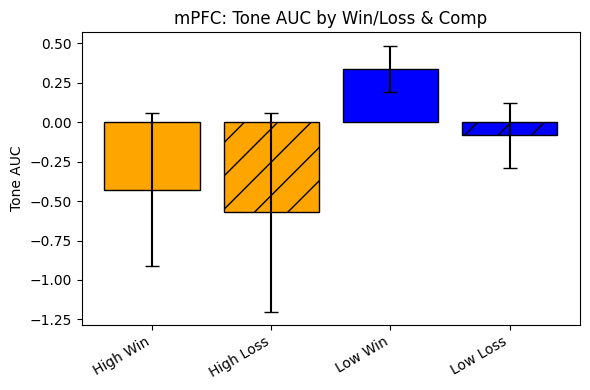

=== Stats for mPFC, metric = Tone Max Peak ===
High Win vs High Loss: nÃ¢â€šÂ=29, nÃ¢â€šâ€š=23, t=-1.002, p=0.321
Low Win  vs Low Loss: nÃ¢â€šÂ=258, nÃ¢â€šâ€š=255, t=-0.063, p=0.949
High Win vs Low Win: nÃ¢â€šÂ=29, nÃ¢â€šâ€š=258, t=-2.620, p=0.009
High Loss vs Low Loss: nÃ¢â€šÂ=23, nÃ¢â€šâ€š=255, t=-0.948, p=0.344


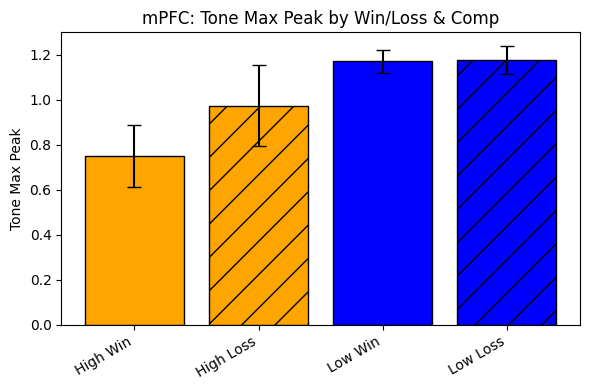

In [ ]:
plot_win_loss_comp_by_region(
    win_df=win_exploded,
    loss_df=loss_exploded,
    region='mPFC',
    metric='Tone AUC'
)

plot_win_loss_comp_by_region(
    win_df=win_exploded,
    loss_df=loss_exploded,
    region='mPFC',
    metric='Tone Max Peak'
)

=== Stats for mPFC, metric = PE AUC ===
High Win vs High Loss: nÃ¢â€šÂ=29, nÃ¢â€šâ€š=23, t=0.045, p=0.964
Low Win  vs Low Loss: nÃ¢â€šÂ=258, nÃ¢â€šâ€š=255, t=5.049, p=0.000
High Win vs Low Win: nÃ¢â€šÂ=29, nÃ¢â€šâ€š=258, t=-0.874, p=0.383
High Loss vs Low Loss: nÃ¢â€šÂ=23, nÃ¢â€šâ€š=255, t=1.208, p=0.228


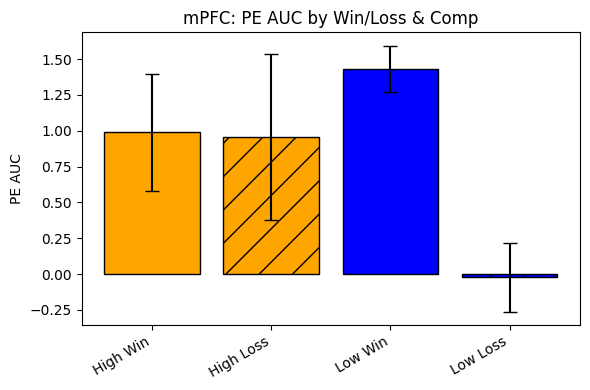

=== Stats for mPFC, metric = PE Max Peak ===
High Win vs High Loss: nÃ¢â€šÂ=29, nÃ¢â€šâ€š=23, t=-1.158, p=0.253
Low Win  vs Low Loss: nÃ¢â€šÂ=258, nÃ¢â€šâ€š=255, t=2.768, p=0.006
High Win vs Low Win: nÃ¢â€šÂ=29, nÃ¢â€šâ€š=258, t=-1.971, p=0.050
High Loss vs Low Loss: nÃ¢â€šÂ=23, nÃ¢â€šâ€š=255, t=0.787, p=0.432


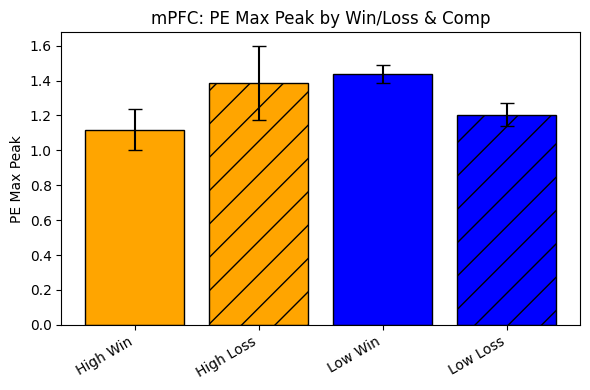

In [ ]:
plot_win_loss_comp_by_region(
    win_df=win_exploded,
    loss_df=loss_exploded,
    region='mPFC',
    metric='PE AUC'
)

plot_win_loss_comp_by_region(
    win_df=win_exploded,
    loss_df=loss_exploded,
    region='mPFC',
    metric='PE Max Peak'
)

## Competitive Bout Probability Over Session\n
\n
Plot the probability of being in a competitive bout as a function of time relative to tone onset. This uses `HVL_Comp` labels aligned to each tone and highlights the tone and reward windows to match the Home Cage-style figure.

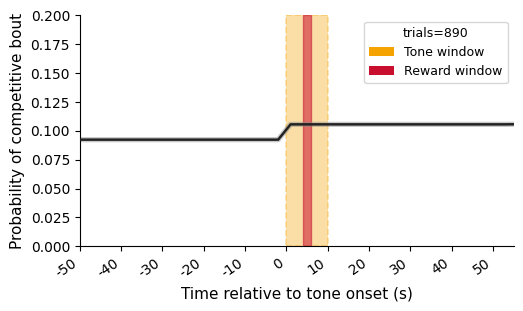

,time_s,probability,sem,n_contributing
0,-50.0,0.092369,0.010601,747
1,-49.0,0.092369,0.010601,747
2,-48.0,0.092369,0.010601,747
3,-47.0,0.092369,0.010601,747
4,-46.0,0.092369,0.010601,747


In [ ]:
# Optional region-specific subsets:\n
# nac_df = rc_exp.da_df[rc_exp.da_df['subject_name'].str.startswith('n')].copy()
# mpfc_df = rc_exp.da_df[rc_exp.da_df['subject_name'].str.startswith('p')].copy()
ax, comp_prob_df, aligned_comp = rc_exp.plot_competitive_bout_probability_over_session(
    df=rc_exp.da_df,
    comp_col='HVL_Comp',
    time_window=(-50, 55),
    tone_window=(0, 10),
    reward_window=(4, 6),
    ylim=(0.0, 0.2),
)
plt.show()

comp_prob_df.head()

## Binned Competitive Bout Activity\n
\n
Create per-trial binary vectors across time bins relative to tone onset. Within each bin, a trial gets `1` if a competitive bout is active anywhere in that bin and `0` otherwise. These binary vectors are then averaged across trials.

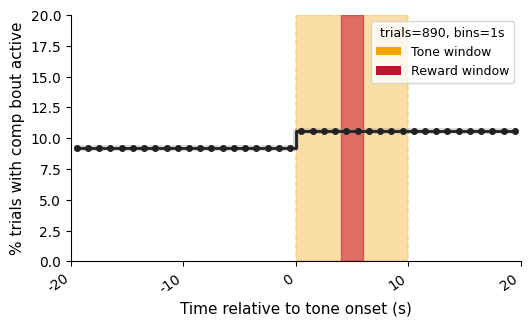

,bin_start_s,bin_end_s,percent_active,proportion_active,n_contributing_trials
0,-20.0,-19.0,9.236948,0.092369,747
1,-19.0,-18.0,9.236948,0.092369,747
2,-18.0,-17.0,9.236948,0.092369,747
3,-17.0,-16.0,9.236948,0.092369,747
4,-16.0,-15.0,9.236948,0.092369,747


In [46]:
bin_width_s = 1.0  # change to 10.0 for 10-second bins\n

ax, binned_comp_df, binned_comp_trials, aligned_comp = rc_exp.plot_binned_competitive_bout_activity(
    df=rc_exp.da_df,
    comp_col='HVL_Comp',
    bin_width_s=bin_width_s,
    sample_step_s=1.0,
    y_mode='percent',
    plot_style='step',
    time_window=(-20, 20),
    tone_window=(0, 10),
    reward_window=(4, 6),
    ylim=(0, 20),
)
plt.show()

binned_comp_df[['bin_start_s', 'bin_end_s', 'percent_active', 'proportion_active', 'n_contributing_trials']].head()

## Session-Level Competitive Bout Metric By Trial\n
\n
Treat each tone-to-next-tone interval as one full trial, including ITI. For each session, compute either the competitive bout count or competitive bout frequency for each trial interval, then average across sessions. Error bars are SEM across sessions.

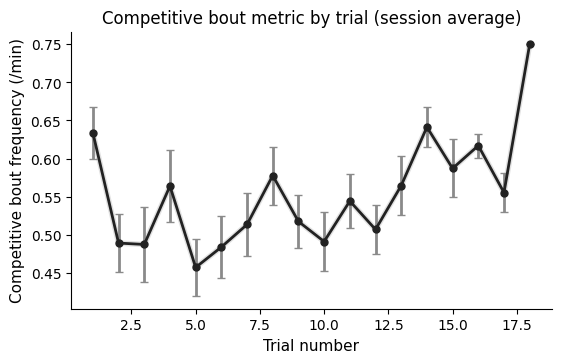

,trial_number,mean_comp_bout_count,sem_comp_bout_count,mean_comp_bout_frequency_hz,sem_comp_bout_frequency_hz,mean_comp_bout_frequency_per_min,sem_comp_bout_frequency_per_min,mean_trial_duration_s,n_sessions
0,1,0.980000,0.020000,0.010565,0.000565,0.633892,0.033909,141.100846,50
1,2,0.800000,0.057143,0.008157,0.000636,0.489409,0.038132,118.700746,50
2,3,0.700000,0.065465,0.008127,0.000824,0.487616,0.049415,102.800608,50
3,4,0.775510,0.060224,0.009402,0.000787,0.564136,0.047199,98.776143,49
4,5,0.791667,0.059238,0.007625,0.000626,0.457488,0.037550,118.229866,48


In [43]:
metric_to_plot = 'frequency_per_min'  # options: 'count', 'frequency_hz', 'frequency_per_min'\n

ax, session_trial_comp_summary, session_trial_comp_long = rc_exp.plot_session_trial_competitive_bout_metric(
    df=rc_exp.da_df,
    cue_col='filtered_sound_cues',
    event_col='filtered_winner_array',
    metric=metric_to_plot,
    deduplicate_sessions=True,
    title='Competitive bout metric by trial (session average)',
)
plt.show()

session_trial_comp_summary.head()

## CSV-Based Competitive Bout Metrics\n
\n
Use timestamped competition bouts from the BORIS-style CSV folder. This collapses subject and social-agent competitive bouts into merged session-level bouts, then computes session-averaged competitive bout count or frequency by trial number. It also supports the pretrial window.

In [ ]:
full_data_folder = r'C:\\Users\\alber\\Downloads\\Full_data\\Full_data'\n
metric_to_plot = 'frequency_per_min'   # options: 'count', 'frequency_hz', 'frequency_per_min'\n
window_to_plot = 'trial'               # options: 'trial', 'pretrial'\n
\n
ax, csv_comp_summary_plot, csv_comp_long, raw_comp_bouts, merged_comp_bouts = rc_exp.plot_csv_session_trial_competitive_bout_metric(\n
    csv_folder=full_data_folder,\n
    df=rc_exp.da_df,\n
    cue_col='filtered_sound_cues',\n
    precomp_col='HVL_PreComp',\n
    comp_col='HVL_Comp',\n
    pretrial_window=(-10, 0),\n
    behavior_name='Competition Bout',\n
    window_type=window_to_plot,\n
    metric=metric_to_plot,\n
    include_pretrial=True,\n
    count_mode='start',\n
    title=f'CSV-based competitive bout {metric_to_plot} by trial ({window_to_plot})',\n
)\n
plt.show()\n
\n
csv_comp_summary_plot.head()